<div style="background-color: #000000; padding: 25px; border-radius: 10px; border-left: 5px solid #007acc; box-shadow: 2px 2px 15px rgba(255,255,255,0.05);">
    <h1 style="color: #ffffff; margin-top: 0;">Sistema Predictivo de Deserción Estudiantil</h1>
    <h3 style="color: #aeb6bf;"><em>Predicción mediante Machine Learning Supervisado</em></h3>
    <hr style="border: 1px solid #333333;">
    <p style="font-size: 16px; color: #ffffff;"><b> Dataset:</b> <code style="background-color: #1e1e1e; color: #d4d4d4; padding: 2px 6px; border-radius: 4px;">dbo.DesercionEstudiantil_PrimerAnio.csv</code></p>
    <p style="color: #cccccc; font-size: 14px; margin-bottom: 0;">
        <strong style="color: #ffffff;">Equipo Investigador:</strong><br>
        Ing. Arévalo Alvarado Raúl Anibal &nbsp;|&nbsp; 
        Ing. Ponce Rodríguez Kevin Enrique &nbsp;|&nbsp; 
        Ing. Hernández Sorto Marcos de Jesús
    </p>
</div>


## 1. Introducción y descripción del problema

### Contexto
Se busca **identificar de manera proactiva a los estudiantes con alto riesgo de deserción** para poder ofrecer intervenciones oportunas y efectivas, como acompañamiento académico, becas, o tutorías personalizadas.

### Problema de Negocio
- **Tipo de Problema:** Clasificación Binaria Supervisada.
- **Variable Objetivo:** `Deserto`. Un valor de `1` indica que el estudiante desertó, mientras que `0` indica que continuó sus estudios.
- **Objetivo del Modelo:** Estimar la probabilidad de que un estudiante deserte en el próximo ciclo académico, basándose en su información académica y administrativa histórica.

### Valor para la Organización
- **Optimización de Recursos:** Permite a la institución priorizar y enfocar sus esfuerzos de retención en los estudiantes que más lo necesitan.
- **Reducción de Costos:** Disminuye los costos asociados a la pérdida de estudiantes y a la captación de nuevos alumnos.
- **Inteligencia de Negocio:** Facilita el monitoreo de indicadores de riesgo clave, permitiendo análisis por carrera, campus o período académico.

### Supuestos Clave
- El dataset contiene registros por estudiante y por ciclo académico.

## 2. Carga y exploración inicial de datos

In [27]:
# 2.1 Importar librerías
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl 
import joblib

# Componentes de Scikit-Learn para preprocesamiento y modelado
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.impute import SimpleImputer

# Métricas para evaluar el rendimiento de los modelos de clasificación
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    recall_score,
    precision_score,
    classification_report, 
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay,
    average_precision_score, PrecisionRecallDisplay
)

# Algoritmos de Machine Learning a evaluar

from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb  # Se utiliza como modelo final

# Configuraciones de Pandas para una mejor visualización de los dataframes
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

### Configuraciones de Pandas para una mejor visualización de los dataframes

In [28]:
# Se define la ruta del archivo y se carga en un DataFrame de Pandas.
import pandas as pd

DATA_PATH = "../Data/dbo.DesercionEstudiantil_PrimerAnio.csv"

df = pd.read_csv(DATA_PATH)

# Asegurarnos de eliminar la columna Carnet para el análisis, tal como fue solicitado
df.drop(columns=['Carnet'], inplace=True, errors='ignore')

# Se define una constante para el tamaño máximo de la muestra.
MAX_SAMPLES = 10000

# Para asegurar la reproducibilidad y eficiencia, se realiza un muestreo estratificado si el dataset es muy grande.
# Uso de train_test_split para evitar el KeyError en la columna objetivo detectado al agrupar.
if len(df) > MAX_SAMPLES:
    from sklearn.model_selection import train_test_split
    # Tomamos MAX_SAMPLES conservando la proporción de clases de "Deserto"
    df_sample, _ = train_test_split(df, train_size=MAX_SAMPLES, stratify=df["Deserto"], random_state=42)
    df = df_sample.reset_index(drop=True)

print(f"Dimensiones del dataset: {df.shape}")
df.head()


Dimensiones del dataset: (10000, 41)


,Carrera,Plan,IdCampus,Sexo,AnioIngreso,CicloIngreso,InstitucionBach,TieneBeca,PorcentajeBeca_Promedio,MateriasInscritas_C1,MateriasAprobadas_C1,MateriasReprobadas_C1,TasaAprobacion_C1,PromedioCiclo_C1,MateriasInscritas_C2,MateriasAprobadas_C2,MateriasReprobadas_C2,TasaAprobacion_C2,PromedioCiclo_C2,TotalMateriasInscritas_Anio1,TotalMateriasAprobadas_Anio1,TotalMateriasReprobadas_Anio1,TasaAprobacion_Anio1,PromedioGeneral_Anio1,AvanceCarrera_FinAnio1,PAES_Score,CantInsolvencias_Recurrentes,CantRetirosParciales,CantRetirosTotales,CantCambiosCarrera,Ind_PAES,Ind_CUM,Ind_Avance,Ind_Solvencia,Ind_RetiroParcial,Ind_RetiroTotal,Ind_CambioCarrera,Ind_Reprobacion,Ind_BrechaDesercion,IRE_Total,Deserto
0,919,2024,9,102302,2024,1,357,0,NaN,5,3,2,0.6,5.07,NaN,NaN,NaN,NaN,NaN,5,3,2,0.6000,5.07,7.5,1.00,5,0,0,0,1,1,1,1,0,0,0,0,0,4,0
1,109,2024,1,102301,2024,1,89,0,NaN,3,0,0,0.0,0.00,NaN,NaN,NaN,NaN,NaN,3,0,0,0.0000,0.00,0.0,0.00,5,0,3,0,1,1,1,1,0,1,0,0,0,5,1
2,109,2017,1,102301,2021,1,468,0,NaN,4,2,1,0.5,5.83,5.0,3.0,2.0,0.6,6.24,9,5,3,0.5556,6.03,27.0,7.87,4,1,0,0,0,1,0,1,0,0,0,0,0,2,0
3,409,2019,1,102301,2023,1,152,0,NaN,5,4,1,0.8,7.82,5.0,4.0,1.0,0.8,7.51,10,8,2,0.8000,7.67,43.7,0.50,8,0,0,0,1,0,0,1,0,0,0,0,0,2,0
4,906,2024,9,102302,2024,1,1133,0,NaN,5,2,2,0.4,4.98,4.0,4.0,0.0,1.0,7.68,9,6,2,0.6667,6.33,8.9,3.50,10,1,0,1,1,1,1,1,0,0,1,0,0,5,0


In [29]:
# 2.3. Longitud del dataset
len(df)

10000

In [30]:
# 2.4. Tipos de datos y resumen general
df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Carrera                        10000 non-null  int64  
 1   Plan                           10000 non-null  int64  
 2   IdCampus                       10000 non-null  int64  
 3   Sexo                           10000 non-null  int64  
 4   AnioIngreso                    10000 non-null  int64  
 5   CicloIngreso                   10000 non-null  int64  
 6   InstitucionBach                10000 non-null  int64  
 7   TieneBeca                      10000 non-null  int64  
 8   PorcentajeBeca_Promedio        610 non-null    float64
 9   MateriasInscritas_C1           10000 non-null  int64  
 10  MateriasAprobadas_C1           10000 non-null  int64  
 11  MateriasReprobadas_C1          10000 non-null  int64  
 12  TasaAprobacion_C1              10000 non-null  float64
 13

In [31]:
# Limpieza y Preparación Inicial de los Datos

# Normaliza nombres de columnas (quita espacios extremos)
df.columns = [str(c).strip() for c in df.columns]

# Eliminación de registros duplicados para evitar redundancia en los datos.
df_before = df.shape[0]
df = df.drop_duplicates()
df_after = df.shape[0]
print(f"[LIMPIEZA] Duplicados eliminados: {df_before - df_after}")

# Limpieza de strings en columnas tipo object
obj_cols = df.select_dtypes(include=["object"]).columns
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip()

# Reemplazo de strings "vacíos" por NaN (para imputación correcta)
df.replace({"": np.nan, "NA": np.nan, "N/A": np.nan, "null": np.nan, "None": np.nan}, inplace=True)

[LIMPIEZA] Duplicados eliminados: 5


,Carrera,Plan,IdCampus,Sexo,AnioIngreso,CicloIngreso,InstitucionBach,TieneBeca,PorcentajeBeca_Promedio,MateriasInscritas_C1,MateriasAprobadas_C1,MateriasReprobadas_C1,TasaAprobacion_C1,PromedioCiclo_C1,MateriasInscritas_C2,MateriasAprobadas_C2,MateriasReprobadas_C2,TasaAprobacion_C2,PromedioCiclo_C2,TotalMateriasInscritas_Anio1,TotalMateriasAprobadas_Anio1,TotalMateriasReprobadas_Anio1,TasaAprobacion_Anio1,PromedioGeneral_Anio1,AvanceCarrera_FinAnio1,PAES_Score,CantInsolvencias_Recurrentes,CantRetirosParciales,CantRetirosTotales,CantCambiosCarrera,Ind_PAES,Ind_CUM,Ind_Avance,Ind_Solvencia,Ind_RetiroParcial,Ind_RetiroTotal,Ind_CambioCarrera,Ind_Reprobacion,Ind_BrechaDesercion,IRE_Total,Deserto
0,919,2024,9,102302,2024,1,357,0,NaN,5,3,2,0.6,5.07,NaN,NaN,NaN,NaN,NaN,5,3,2,0.6000,5.07,7.5,1.00,5,0,0,0,1,1,1,1,0,0,0,0,0,4,0
1,109,2024,1,102301,2024,1,89,0,NaN,3,0,0,0.0,0.00,NaN,NaN,NaN,NaN,NaN,3,0,0,0.0000,0.00,0.0,0.00,5,0,3,0,1,1,1,1,0,1,0,0,0,5,1
2,109,2017,1,102301,2021,1,468,0,NaN,4,2,1,0.5,5.83,5.0,3.0,2.0,0.60,6.24,9,5,3,0.5556,6.03,27.0,7.87,4,1,0,0,0,1,0,1,0,0,0,0,0,2,0
3,409,2019,1,102301,2023,1,152,0,NaN,5,4,1,0.8,7.82,5.0,4.0,1.0,0.80,7.51,10,8,2,0.8000,7.67,43.7,0.50,8,0,0,0,1,0,0,1,0,0,0,0,0,2,0
4,906,2024,9,102302,2024,1,1133,0,NaN,5,2,2,0.4,4.98,4.0,4.0,0.0,1.00,7.68,9,6,2,0.6667,6.33,8.9,3.50,10,1,0,1,1,1,1,1,0,0,1,0,0,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,301,2018,1,102301,2021,1,349,0,NaN,4,0,4,0.0,2.19,4.0,2.0,2.0,0.50,4.52,8,2,6,0.2500,3.36,0.0,7.80,4,0,0,1,0,1,1,1,0,0,1,0,0,4,0
9996,209,2024,1,102302,2024,1,75,0,NaN,5,0,3,0.0,2.67,4.0,1.0,2.0,0.25,2.66,9,1,5,0.1111,2.66,0.0,1.00,10,3,0,1,1,1,1,1,1,0,1,0,0,6,0
9997,206,2024,1,102302,2024,1,245,0,NaN,3,3,0,1.0,6.73,3.0,3.0,0.0,1.00,8.19,6,6,0,1.0000,7.46,38.1,1.00,10,0,0,0,1,0,0,1,0,0,0,0,0,2,0
9998,403,2019,1,102301,2022,1,228,0,NaN,5,0,0,0.0,0.00,NaN,NaN,NaN,NaN,NaN,5,0,0,0.0000,0.00,0.0,0.00,4,0,5,0,1,1,1,1,0,1,0,0,0,5,1


### Exploración de la Variable Objetivo 'Deserto'

Validamos que `Deserto` sea binaria y revisamos el balance de clases.

In [32]:
df.columns = df.columns.str.strip()


print("Columnas en el dataset:", df.columns.tolist())
print("-" * 50)


target_col = "Deserto"
print("Valores únicos en Deserto:", sorted(df[target_col].dropna().unique()))
display(df[target_col].value_counts(dropna=False))

Columnas en el dataset: ['Carrera', 'Plan', 'IdCampus', 'Sexo', 'AnioIngreso', 'CicloIngreso', 'InstitucionBach', 'TieneBeca', 'PorcentajeBeca_Promedio', 'MateriasInscritas_C1', 'MateriasAprobadas_C1', 'MateriasReprobadas_C1', 'TasaAprobacion_C1', 'PromedioCiclo_C1', 'MateriasInscritas_C2', 'MateriasAprobadas_C2', 'MateriasReprobadas_C2', 'TasaAprobacion_C2', 'PromedioCiclo_C2', 'TotalMateriasInscritas_Anio1', 'TotalMateriasAprobadas_Anio1', 'TotalMateriasReprobadas_Anio1', 'TasaAprobacion_Anio1', 'PromedioGeneral_Anio1', 'AvanceCarrera_FinAnio1', 'PAES_Score', 'CantInsolvencias_Recurrentes', 'CantRetirosParciales', 'CantRetirosTotales', 'CantCambiosCarrera', 'Ind_PAES', 'Ind_CUM', 'Ind_Avance', 'Ind_Solvencia', 'Ind_RetiroParcial', 'Ind_RetiroTotal', 'Ind_CambioCarrera', 'Ind_Reprobacion', 'Ind_BrechaDesercion', 'IRE_Total', 'Deserto']
--------------------------------------------------
Valores únicos en Deserto: [np.int64(0), np.int64(1)]


Deserto
0    7047
1    2948
Name: count, dtype: int64

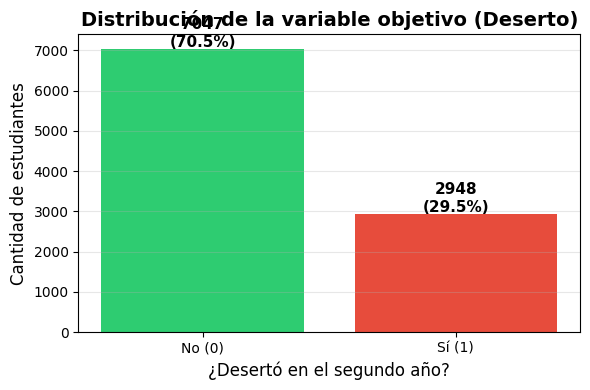


 Proporciones de clase:
Deserto
0    0.7051
1    0.2949
Name: count, dtype: float64


In [33]:
# Distribución (balance) de clases
counts = df[target_col].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(counts.index.astype(str), counts.values, color=['#2ecc71', '#e74c3c'])
plt.title("Distribución de la variable objetivo (Deserto)", fontsize=14, fontweight='bold')
plt.xlabel("¿Desertó en el segundo año?", fontsize=12)
plt.ylabel("Cantidad de estudiantes", fontsize=12)
plt.xticks(ticks=range(len(counts)), labels=['No (0)', 'Sí (1)'], rotation=0)
plt.grid(axis='y', alpha=0.3)

# Agregar etiquetas con porcentajes
for i, (idx, val) in enumerate(counts.items()):
    pct = 100 * val / counts.sum()
    plt.text(i, val + 50, f'{val}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Proporciones de clase:")
proportions = (counts / counts.sum()).round(4)
print(proportions)

## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Preparación: identificar variables numéricas y categóricas

Como el dataset contiene **códigos** (por ejemplo `Carrera`, `Plan`, `InstitucionBach`), se separan columnas en:
- **Numéricas continuas / de conteo** (útiles para histogramas y correlación).
- **Categóricas codificadas** (útiles para conteos por categoría).


In [34]:

# Identificación de variables categóricas y numéricas
print("IDENTIFICACIÓN DE TIPOS DE VARIABLES")

# Heurística: columnas con baja cardinalidad suelen comportarse como categóricas (aunque sean int)
nunique = df.nunique()
low_cardinality_cols = nunique[nunique <= 30].index.tolist() # Se consideran categóricas aquellas con 30 o menos valores únicos.

# Objetivo no se considera feature
if target_col in low_cardinality_cols:
    low_cardinality_cols.remove(target_col)

# Candidate categóricas: baja cardinalidad + tipo int/obj
categorical_cols = [c for c in low_cardinality_cols if df[c].dtype == 'object' or df[c].dtype == 'int64']

# Se definen listas para forzar la clasificación de ciertas columnas, corrigiendo posibles detecciones erróneas.
forced_categorical = ["InstitucionBach", "Carrera", "Plan", "IdCampus", "Sexo"]
forced_numeric = ["MateriasInscritas_C1", "MateriasAprobadas_C1", "MateriasReprobadas_C1", "MateriasInscritas_C2", "MateriasAprobadas_C2", "MateriasReprobadas_C2", "TotalMateriasInscritas_Anio1", "TotalMateriasAprobadas_Anio1", "TotalMateriasReprobadas_Anio1"]

for col in forced_categorical:
    if col in df.columns and col not in categorical_cols:
        categorical_cols.append(col)

# Eliminar de categóricas si fueron forzadas a numéricas
for col in forced_numeric:
    if col in categorical_cols:
        categorical_cols.remove(col)

# Candidate numéricas: el resto (incluye float, conteos con alta cardinalidad)
numeric_cols = [c for c in df.columns if c not in categorical_cols + [target_col]]

for col in forced_numeric:
    if col in df.columns and col not in numeric_cols:
        numeric_cols.append(col)

print(f"\n Columnas categóricas detectadas ({len(categorical_cols)}):")
print(categorical_cols)
print(f"\n Columnas numéricas detectadas ({len(numeric_cols)}):")
print(numeric_cols)

IDENTIFICACIÓN DE TIPOS DE VARIABLES

 Columnas categóricas detectadas (22):
['Plan', 'IdCampus', 'Sexo', 'AnioIngreso', 'CicloIngreso', 'TieneBeca', 'CantInsolvencias_Recurrentes', 'CantRetirosParciales', 'CantRetirosTotales', 'CantCambiosCarrera', 'Ind_PAES', 'Ind_CUM', 'Ind_Avance', 'Ind_Solvencia', 'Ind_RetiroParcial', 'Ind_RetiroTotal', 'Ind_CambioCarrera', 'Ind_Reprobacion', 'Ind_BrechaDesercion', 'IRE_Total', 'InstitucionBach', 'Carrera']

 Columnas numéricas detectadas (18):
['PorcentajeBeca_Promedio', 'MateriasInscritas_C1', 'MateriasAprobadas_C1', 'MateriasReprobadas_C1', 'TasaAprobacion_C1', 'PromedioCiclo_C1', 'MateriasInscritas_C2', 'MateriasAprobadas_C2', 'MateriasReprobadas_C2', 'TasaAprobacion_C2', 'PromedioCiclo_C2', 'TotalMateriasInscritas_Anio1', 'TotalMateriasAprobadas_Anio1', 'TotalMateriasReprobadas_Anio1', 'TasaAprobacion_Anio1', 'PromedioGeneral_Anio1', 'AvanceCarrera_FinAnio1', 'PAES_Score']


### 3.2 Análisis univariado

- Distribuciones de variables numéricas (histogramas).
- Outliers con boxplots (muestra rápida).
- Conteos para variables categóricas.


ANÁLISIS DE VARIABLES NUMÉRICAS


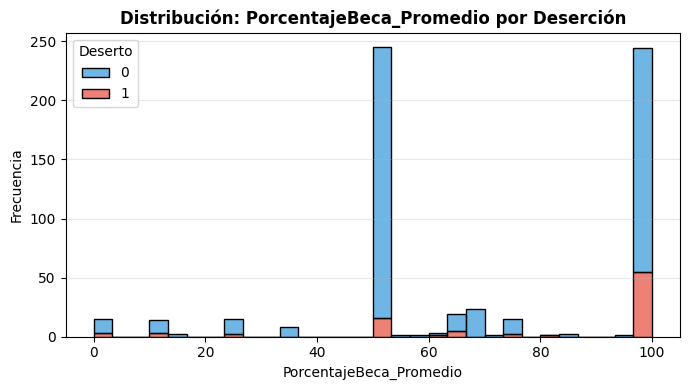

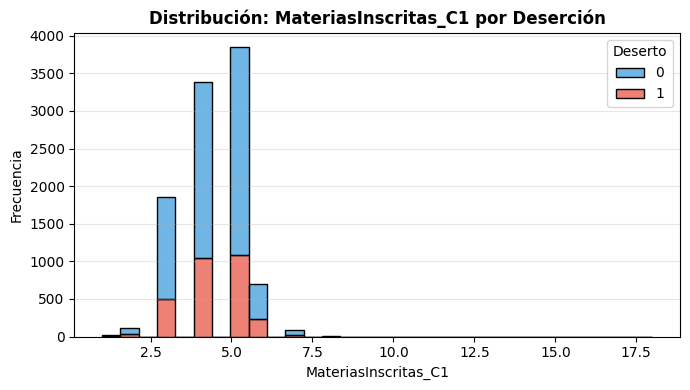

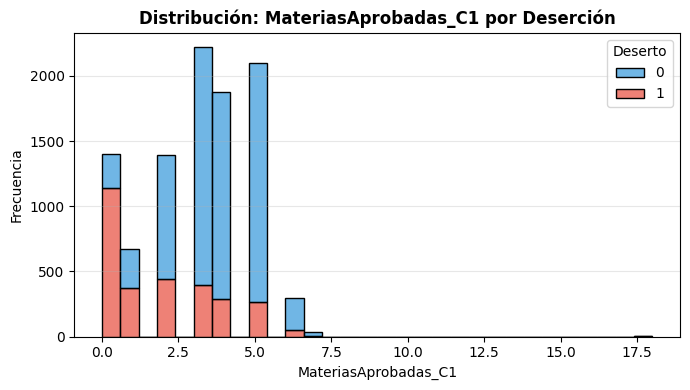

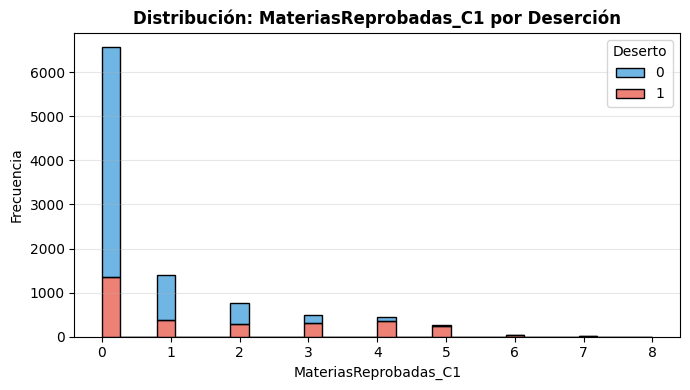

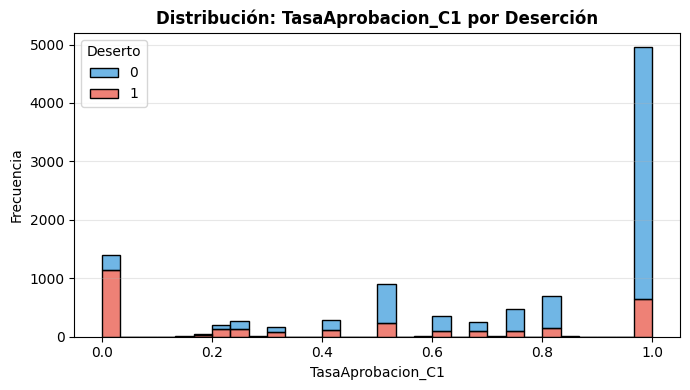

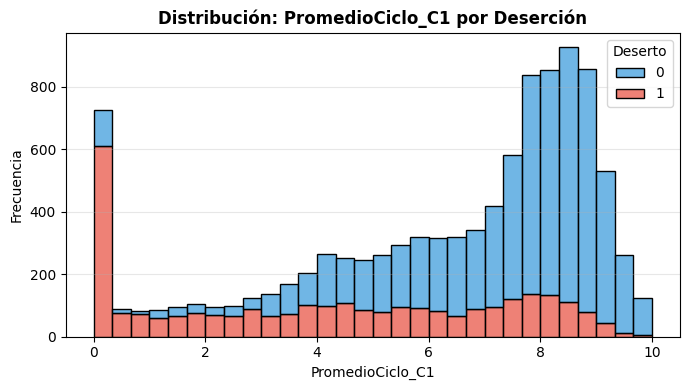

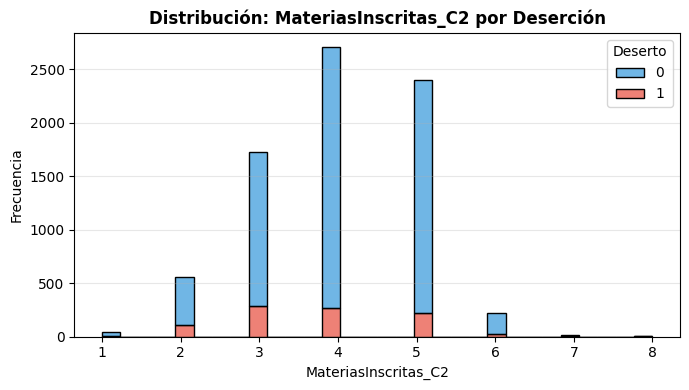

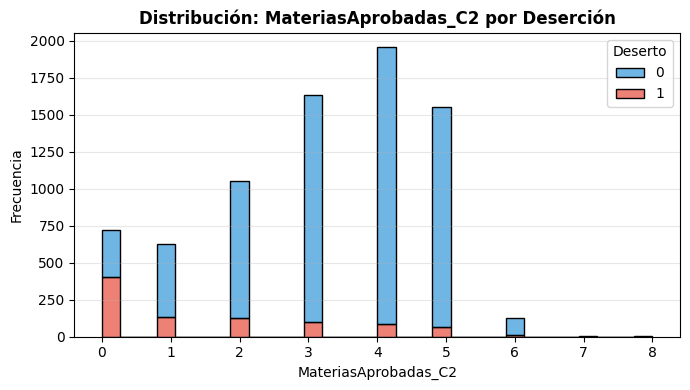

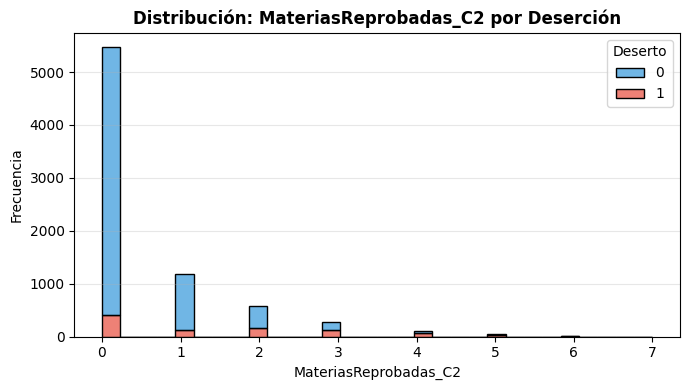

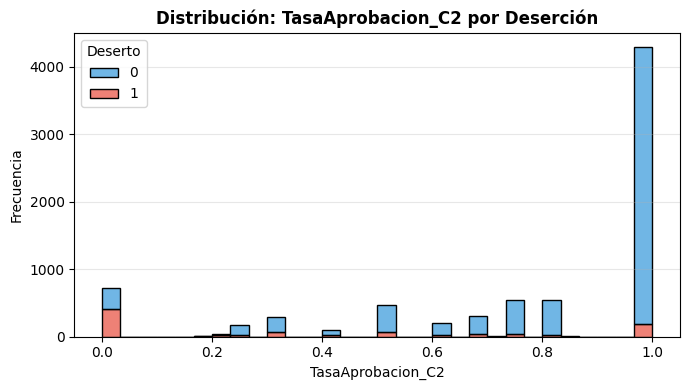

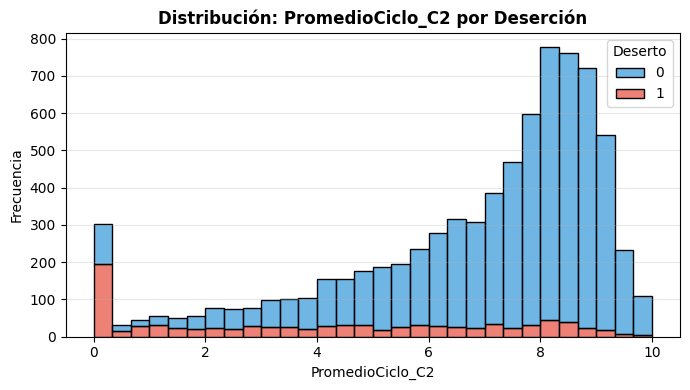

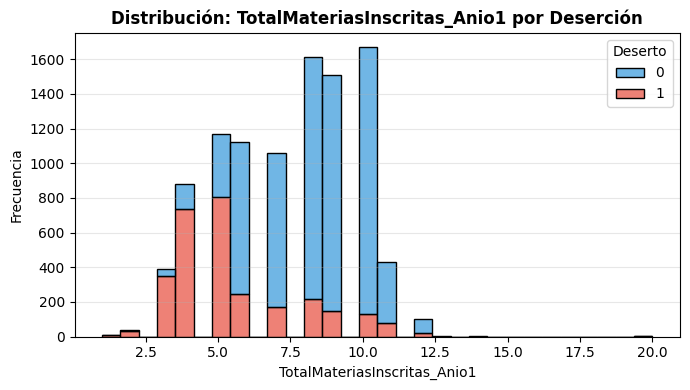

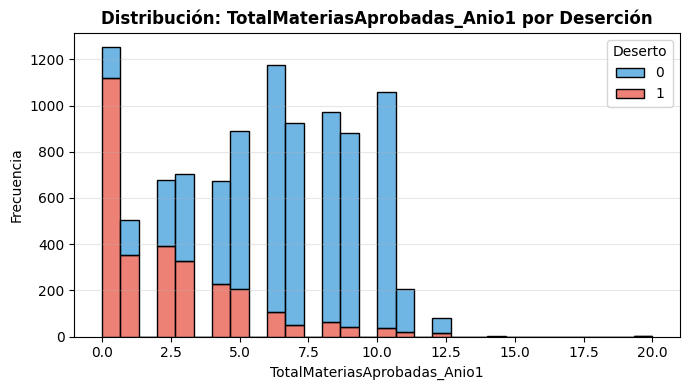

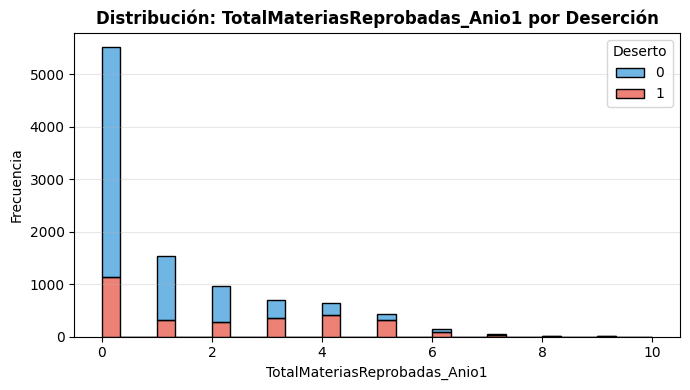

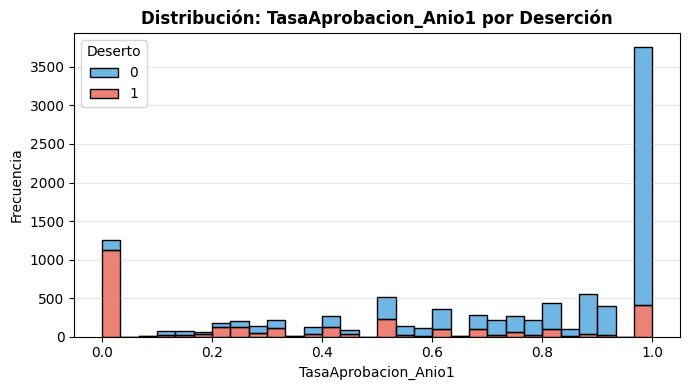

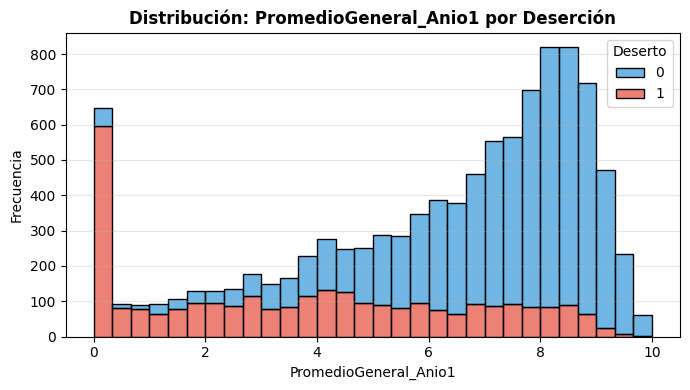

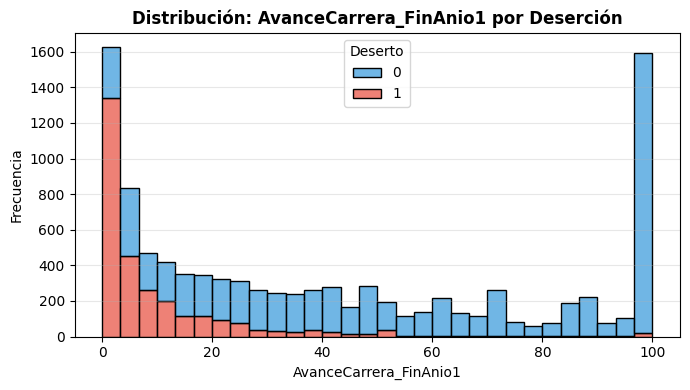

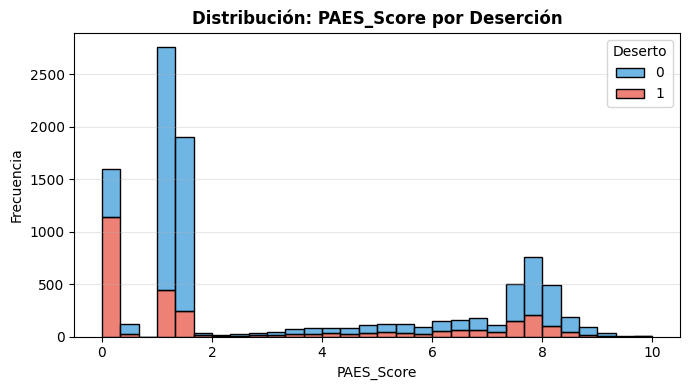

In [35]:
print("ANÁLISIS DE VARIABLES NUMÉRICAS")

import seaborn as sns
# Histogramas de variables numéricas separadas por clase
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, hue=target_col, multiple="stack", bins=30, edgecolor="black", alpha=0.7, palette={0: "#3498db", 1: "#e74c3c"})
    plt.title(f"Distribución: {col} por Deserción", fontsize=12, fontweight="bold")
    plt.xlabel(col, fontsize=10)
    plt.ylabel("Frecuencia", fontsize=10)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


ANÁLISIS DE VARIABLES CATEGÓRICAS


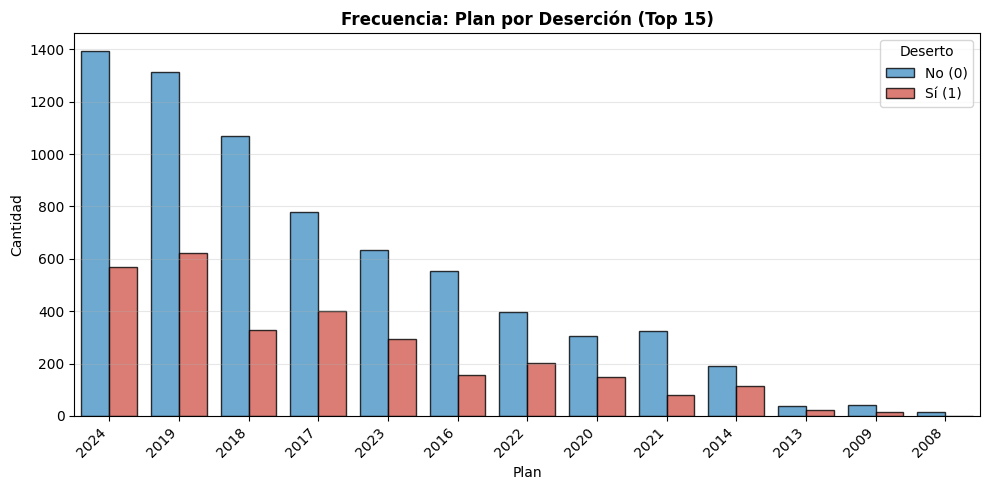

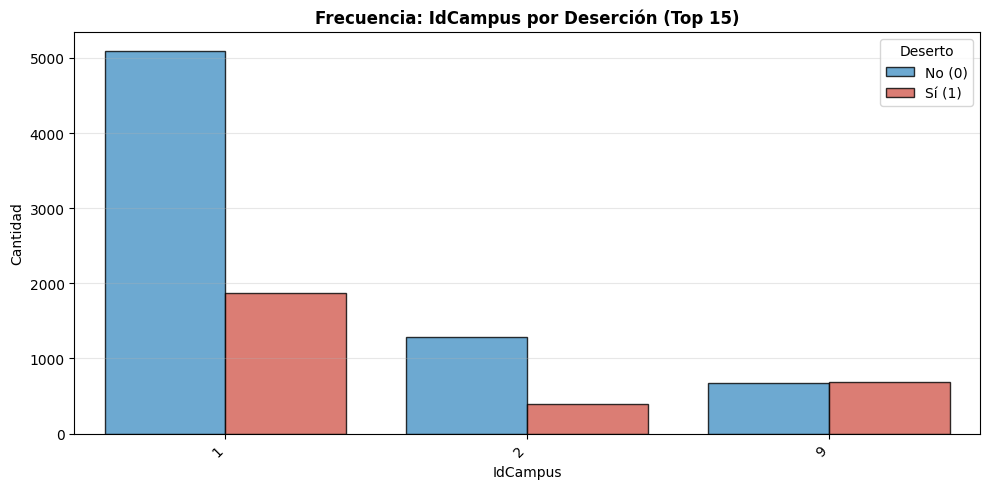

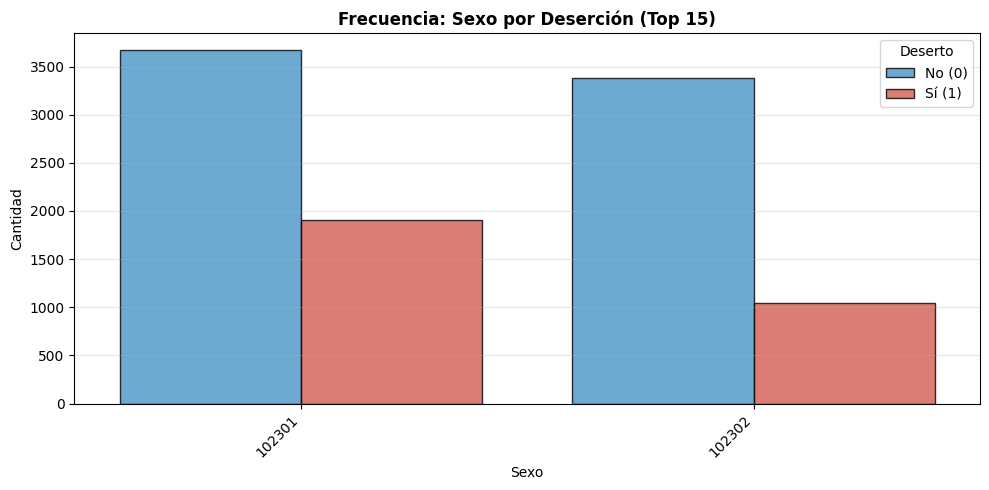

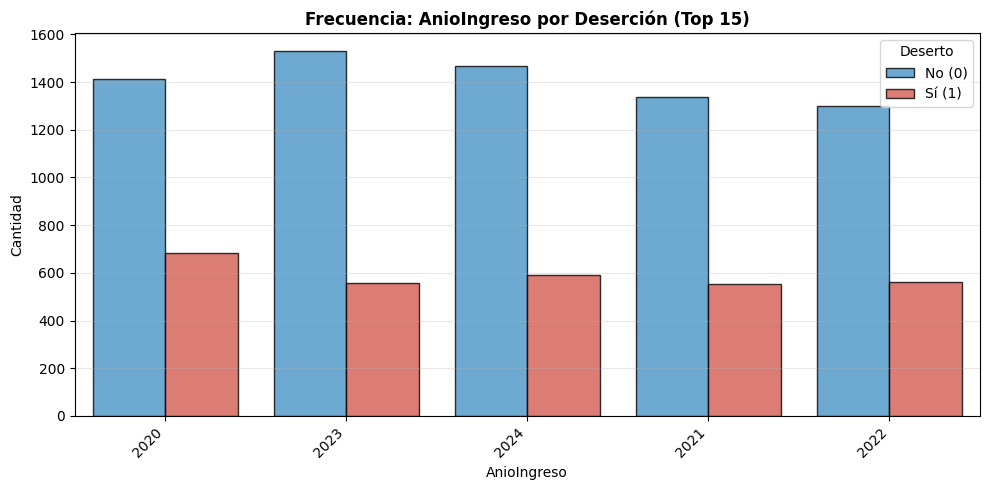

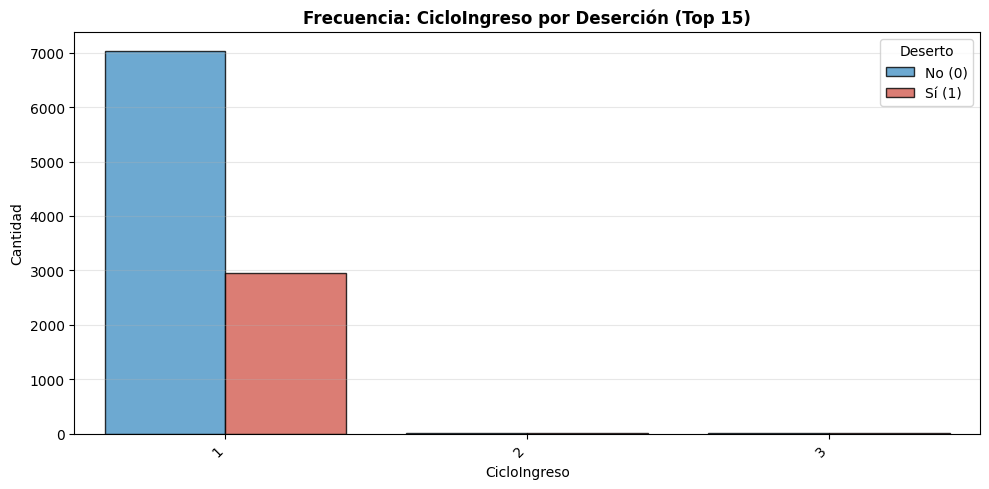

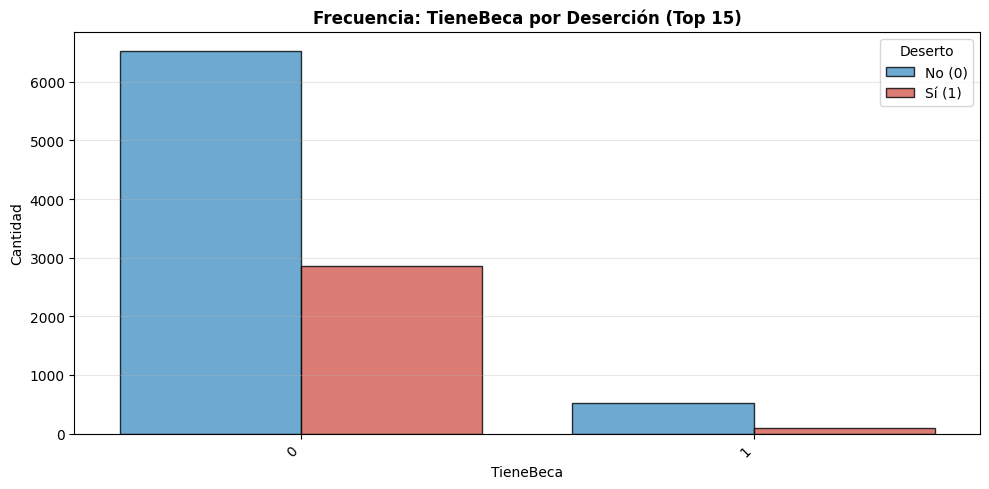

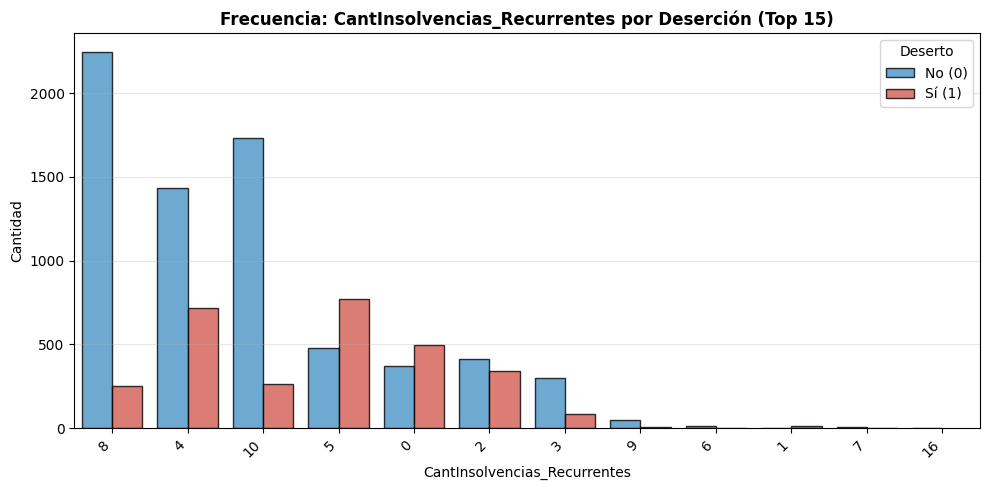

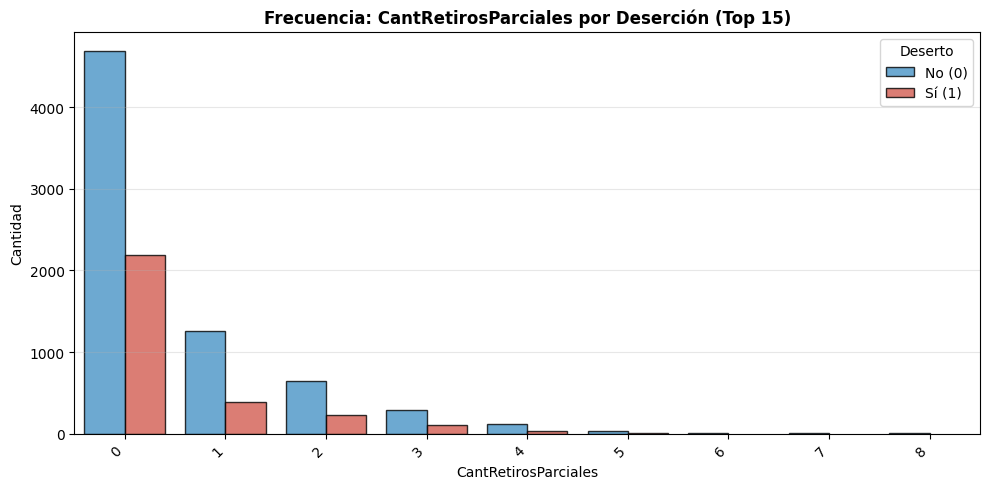

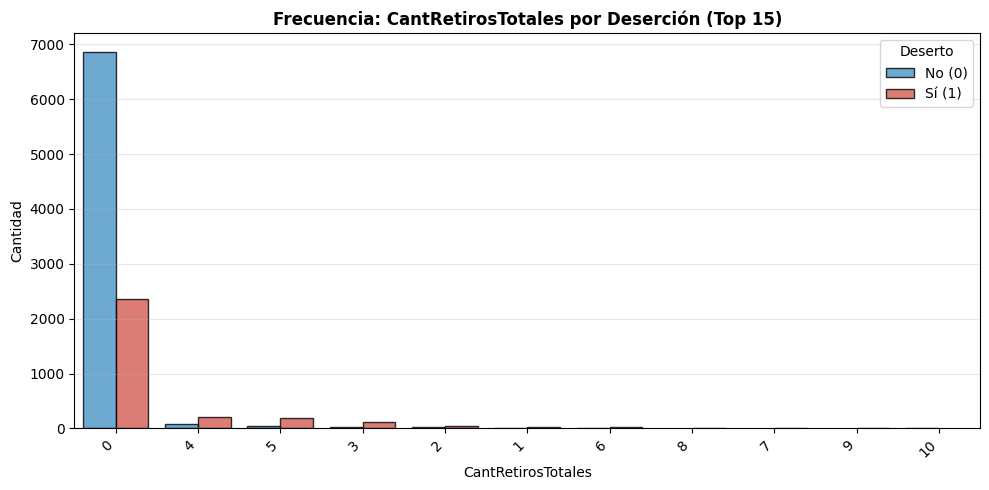

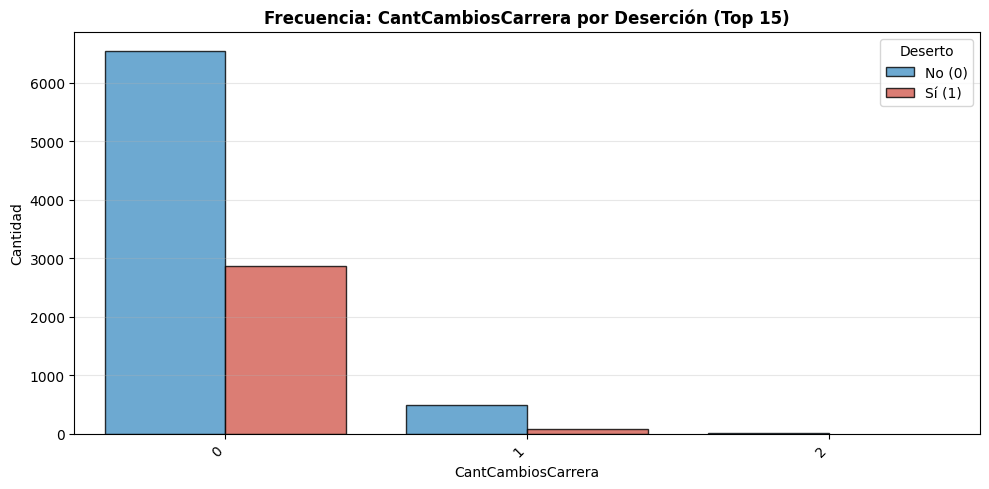

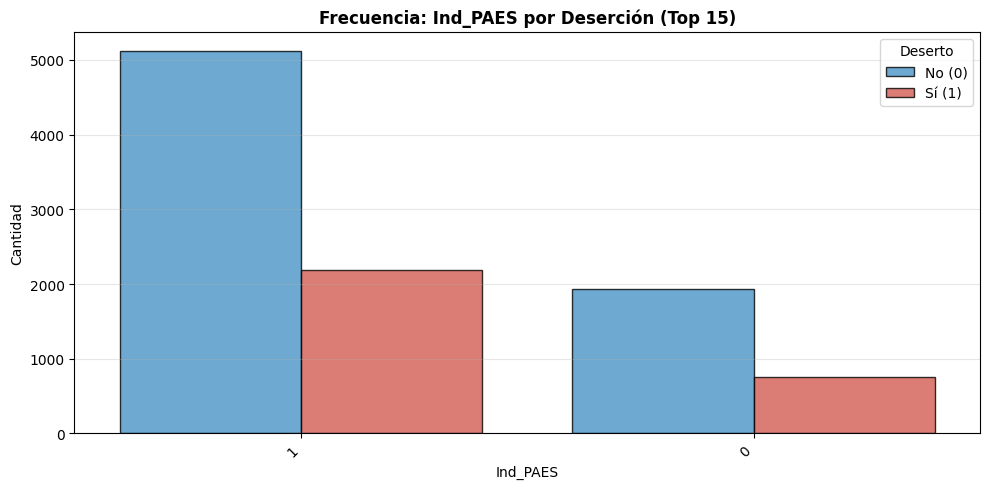

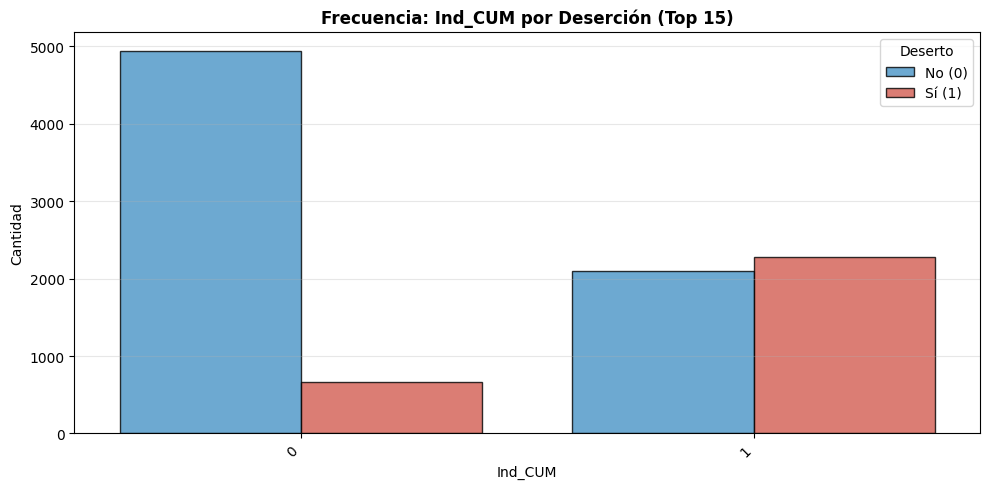

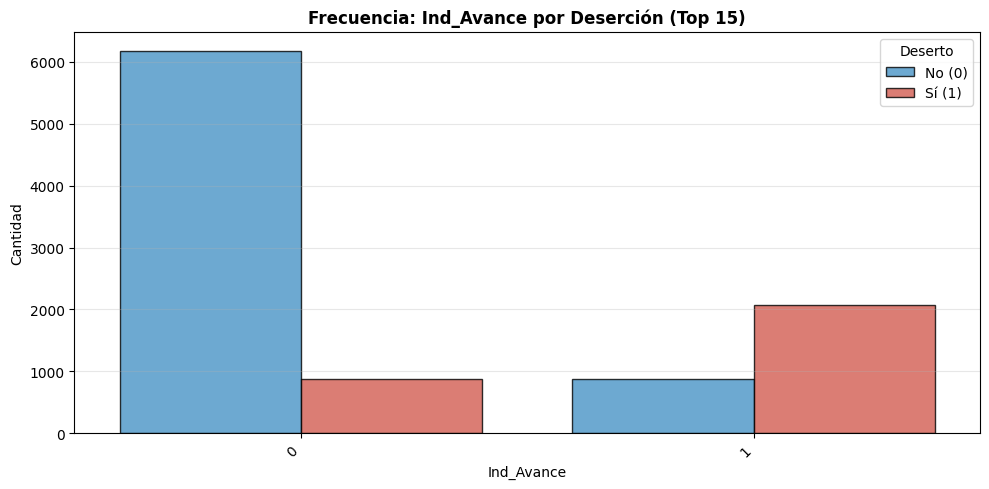

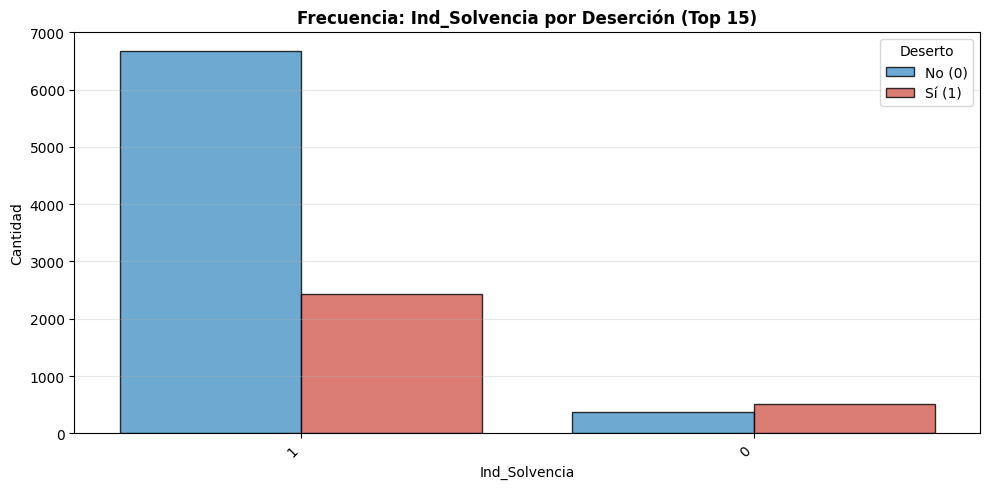

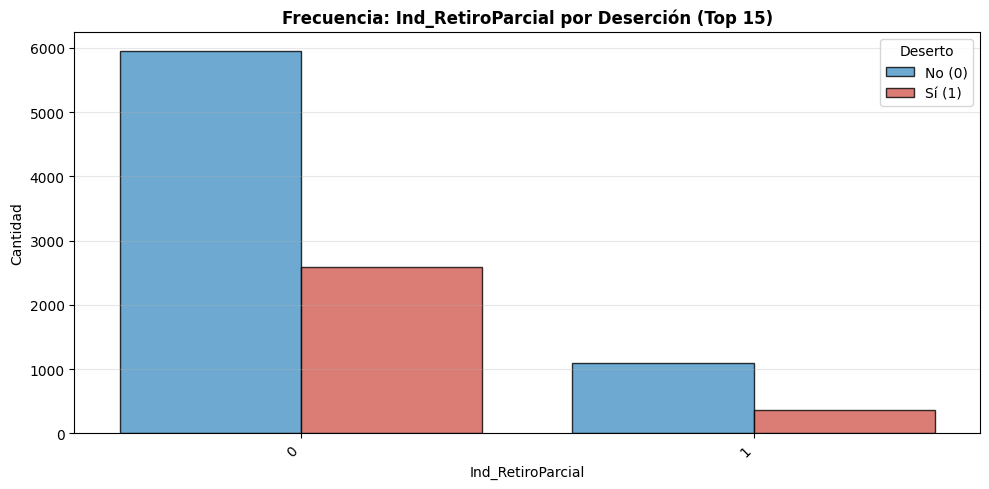

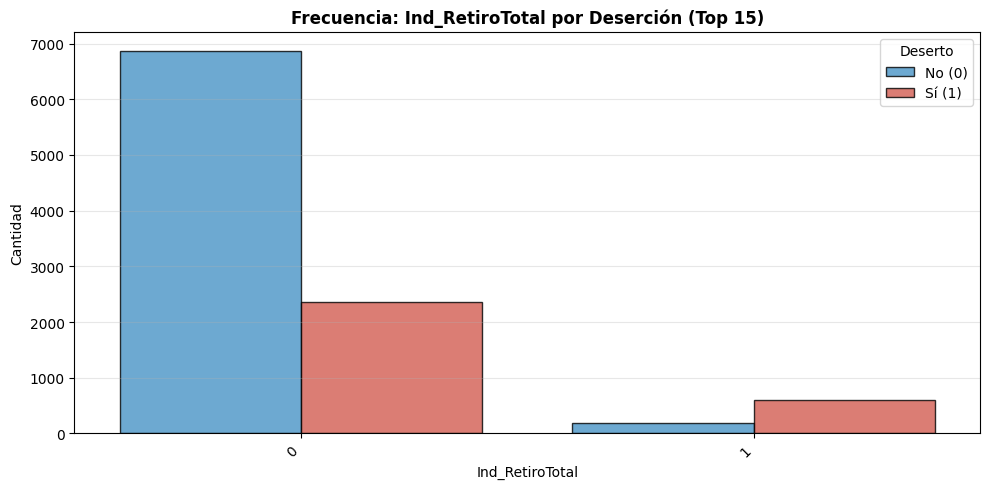

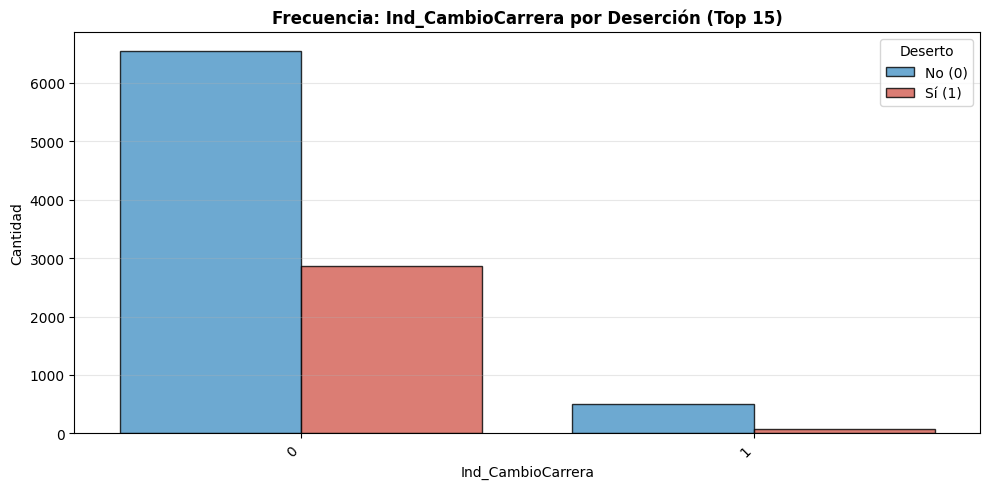

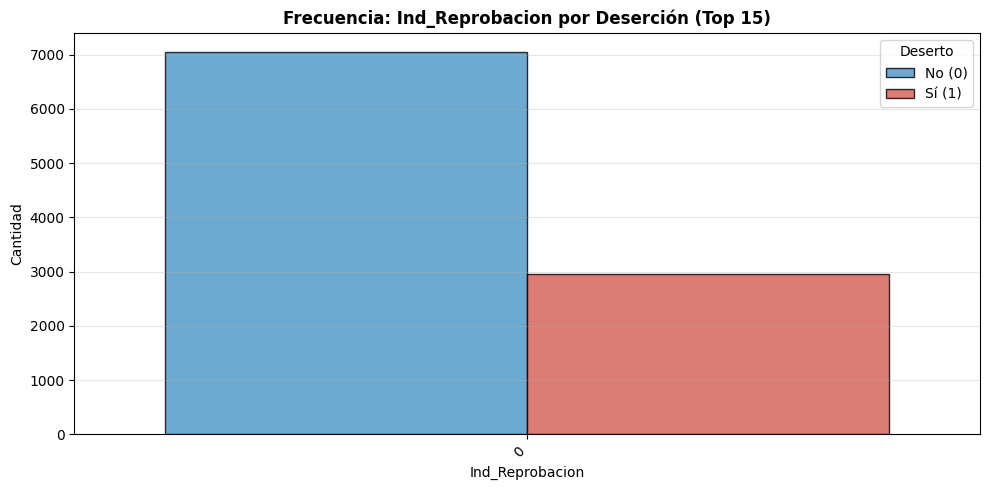

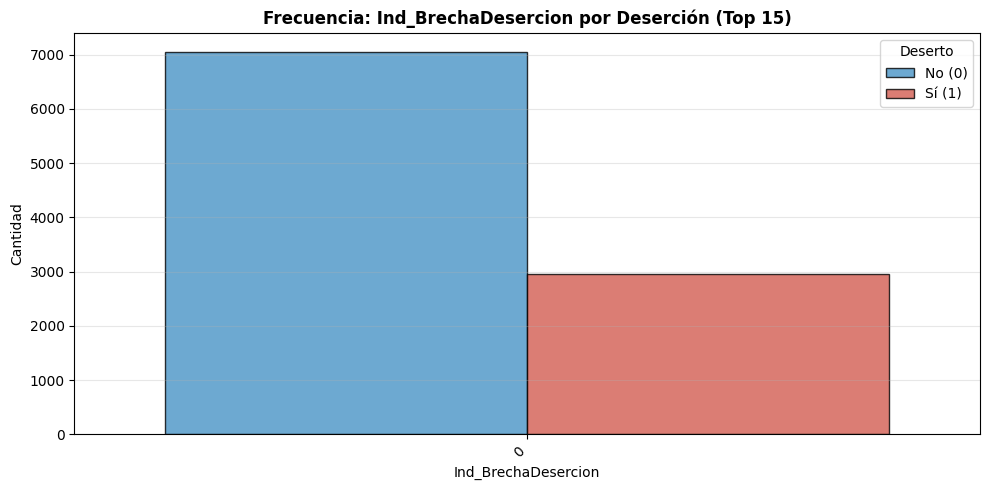

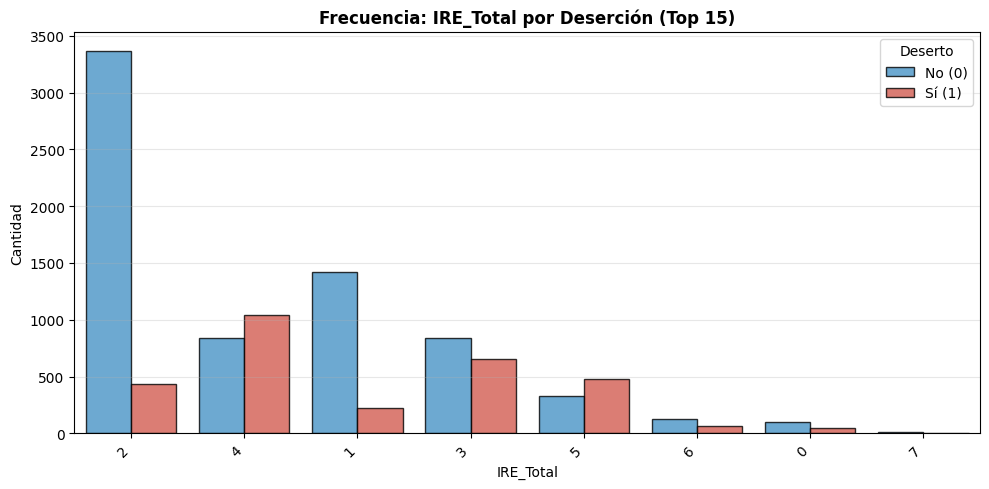

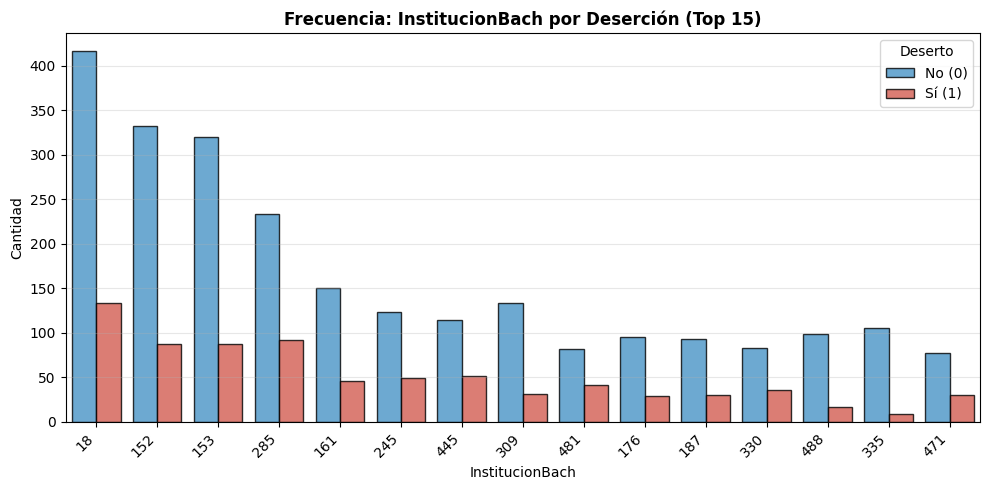

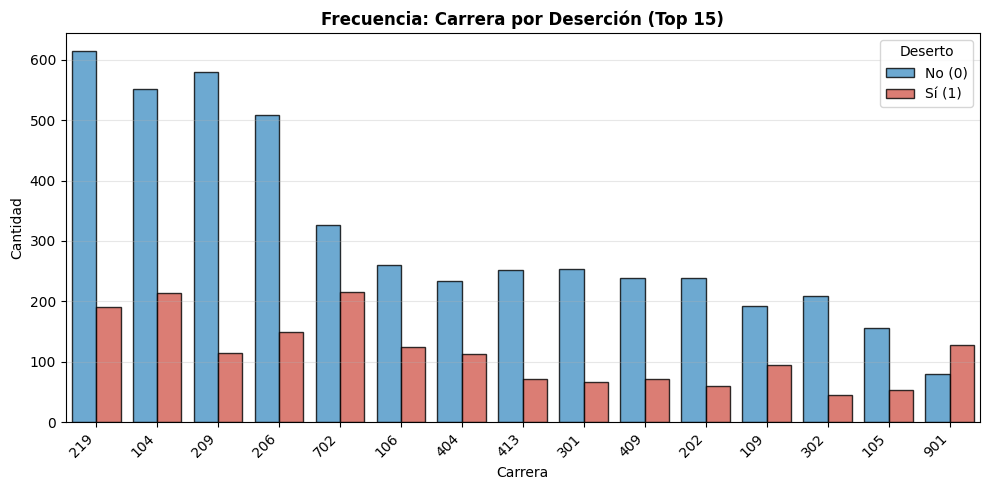

In [36]:

# Análisis de variables categóricas
print("ANÁLISIS DE VARIABLES CATEGÓRICAS")

import seaborn as sns
# Conteos de variables categóricas separadas por clase
for col in categorical_cols:
    top_cats = df[col].value_counts().head(15).index  # top 15 categorías
    df_top = df[df[col].isin(top_cats)]
    
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df_top, x=col, hue=target_col, order=top_cats, palette={0: "#3498db", 1: "#e74c3c"}, edgecolor="black", alpha=0.8)
    plt.title(f"Frecuencia: {col} por Deserción (Top 15)", fontsize=12, fontweight="bold")
    plt.xlabel(col, fontsize=10)
    plt.ylabel("Cantidad", fontsize=10)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.legend(title="Deserto", labels=["No (0)", "Sí (1)"])
    plt.tight_layout()
    plt.show()


### 3.3 Valores faltantes (missing values)

- Se calcula el porcentaje de nulos por columna.
- Se visualiza un resumen.


ANÁLISIS DE VALORES NULOS

 Columnas con valores nulos: 6

Top de columnas con mayor porcentaje de nulos:
PorcentajeBeca_Promedio    0.938969
TasaAprobacion_C2          0.233017
MateriasInscritas_C2       0.233017
MateriasReprobadas_C2      0.233017
PromedioCiclo_C2           0.233017
MateriasAprobadas_C2       0.233017
dtype: float64


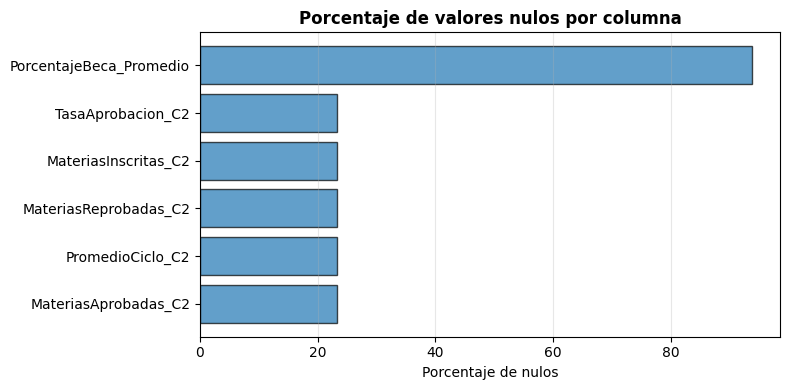

In [37]:

# 3.5. Análisis de valores nulos

print("ANÁLISIS DE VALORES NULOS")

missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]

print(f"\n Columnas con valores nulos: {len(missing)}")
if len(missing) > 0:
    print("\nTop de columnas con mayor porcentaje de nulos:")
    print(missing.head(20))
    
    # Gráfico de porcentaje de nulos por columna
    plt.figure(figsize=(8, max(4, 0.3*len(missing))))
    plt.barh(missing.index[::-1], (missing.values[::-1]*100), edgecolor='black', alpha=0.7)
    plt.title("Porcentaje de valores nulos por columna", fontsize=12, fontweight='bold')
    plt.xlabel("Porcentaje de nulos", fontsize=10)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\n No hay valores nulos en el dataset.")

### 3.4 Análisis bivariado/multivariado

- Relación de cada feature con `Deserto`.
- Correlación entre variables numéricas.


CORRELACIÓN CON LA VARIABLE OBJETIVO

Top correlaciones con 'Deserto':
TotalMateriasAprobadas_Anio1    -0.608621
TasaAprobacion_Anio1            -0.569092
PromedioGeneral_Anio1           -0.562325
AvanceCarrera_FinAnio1          -0.554742
TotalMateriasInscritas_Anio1    -0.533070
PromedioCiclo_C1                -0.506622
TasaAprobacion_C1               -0.504212
MateriasAprobadas_C1            -0.461252
TasaAprobacion_C2               -0.429925
PromedioCiclo_C2                -0.413988
MateriasReprobadas_C1            0.386278
MateriasAprobadas_C2            -0.370545
MateriasReprobadas_C2            0.349936
TotalMateriasReprobadas_Anio1    0.333203
PorcentajeBeca_Promedio          0.152143
Name: Deserto, dtype: float64


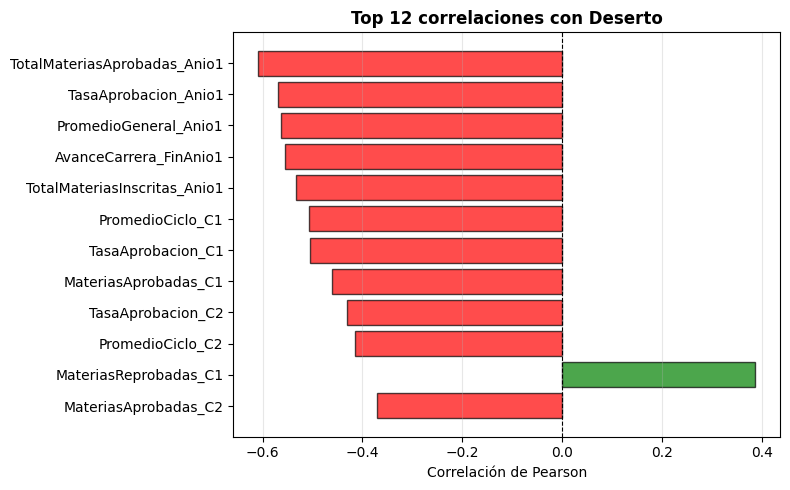

In [38]:

print("CORRELACIÓN CON LA VARIABLE OBJETIVO")

# Correlación con la variable objetivo (solo numéricas)
corr = df[numeric_cols + [target_col]].corr(numeric_only=True)[target_col].drop(target_col).sort_values(key=lambda s: s.abs(), ascending=False)

print("\nTop correlaciones con 'Deserto':")
print(corr.head(15))

# Gráfico: Top correlaciones absolutas con Deserto
topk = min(12, len(corr))
top_corr = corr.iloc[:topk][::-1]

plt.figure(figsize=(8, 5))
colors = ['red' if x < 0 else 'green' for x in top_corr.values]
plt.barh(top_corr.index, top_corr.values, color=colors, edgecolor='black', alpha=0.7)
plt.title(f"Top {topk} correlaciones con Deserto", fontsize=12, fontweight='bold')
plt.xlabel("Correlación de Pearson", fontsize=10)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


TASA DE DESERCIÓN POR CATEGORÍA

--- Tasa de deserción por Plan ---
      count  tasa_desercion
Plan                       
2024   1960        0.289286
2019   1936        0.321281
2018   1396        0.234957
2017   1178        0.340407
2023    927        0.314995
2016    710        0.222535
2022    596        0.337248
2020    452        0.327434
2021    407        0.199017
2014    306        0.375817


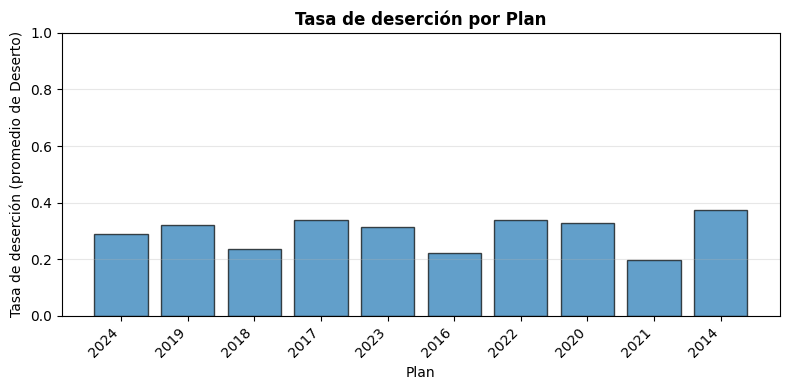


--- Tasa de deserción por IdCampus ---
          count  tasa_desercion
IdCampus                       
1          6965        0.268916
2          1679        0.234663
9          1351        0.504071


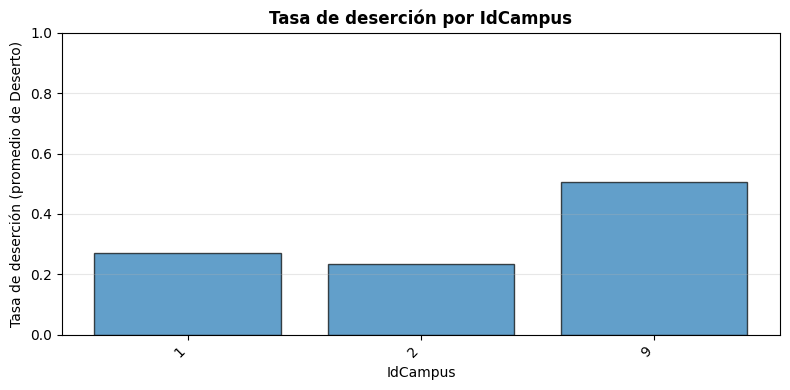


--- Tasa de deserción por Sexo ---
        count  tasa_desercion
Sexo                         
102301   5570        0.341652
102302   4425        0.236158


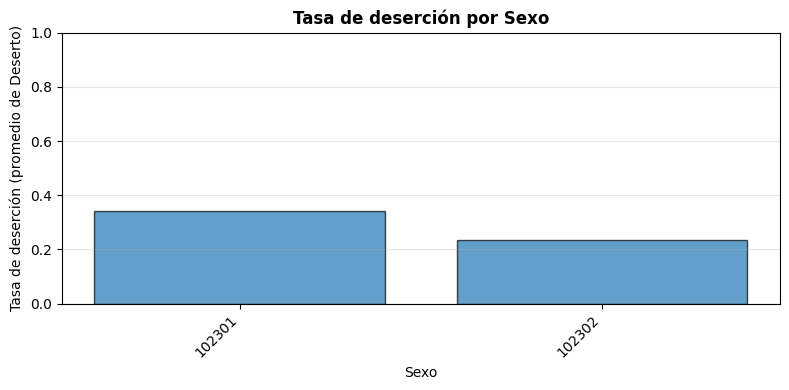


--- Tasa de deserción por AnioIngreso ---
             count  tasa_desercion
AnioIngreso                       
2020          2094        0.325692
2023          2087        0.266890
2024          2060        0.287864
2021          1892        0.293340
2022          1862        0.301289


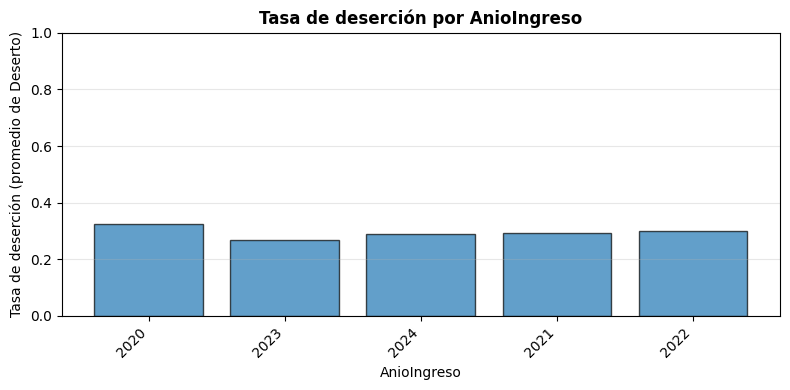


--- Tasa de deserción por CicloIngreso ---
              count  tasa_desercion
CicloIngreso                       
1              9974        0.294967
2                11        0.363636
3                10        0.200000


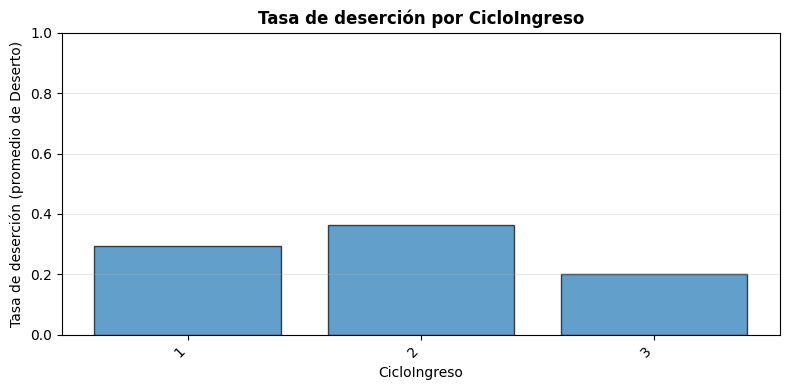


--- Tasa de deserción por TieneBeca ---
           count  tasa_desercion
TieneBeca                       
0           9385        0.304742
1            610        0.144262


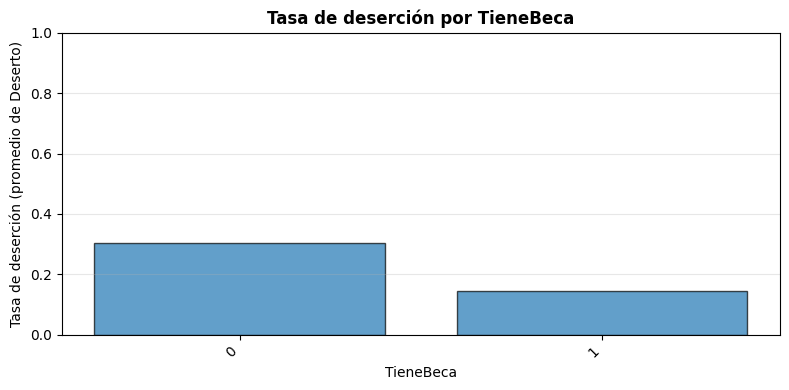


--- Tasa de deserción por CantInsolvencias_Recurrentes ---
                              count  tasa_desercion
CantInsolvencias_Recurrentes                       
8                              2501        0.101559
4                              2150        0.333953
10                             1996        0.132265
5                              1245        0.616867
0                               869        0.571922
2                               757        0.451783
3                               388        0.224227
9                                54        0.092593
6                                16        0.062500
1                                12        0.833333


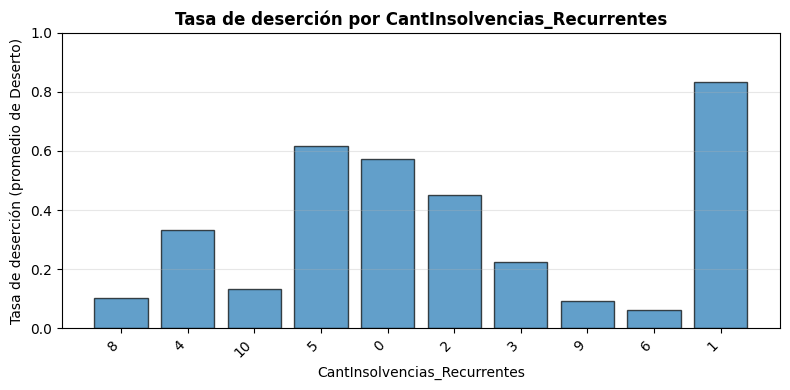


--- Tasa de deserción por CantRetirosParciales ---
                      count  tasa_desercion
CantRetirosParciales                       
0                      6887        0.318716
1                      1646        0.235723
2                       876        0.261416
3                       384        0.257812
4                       149        0.194631
5                        41        0.195122
6                         8        0.000000
7                         3        0.000000
8                         1        0.000000


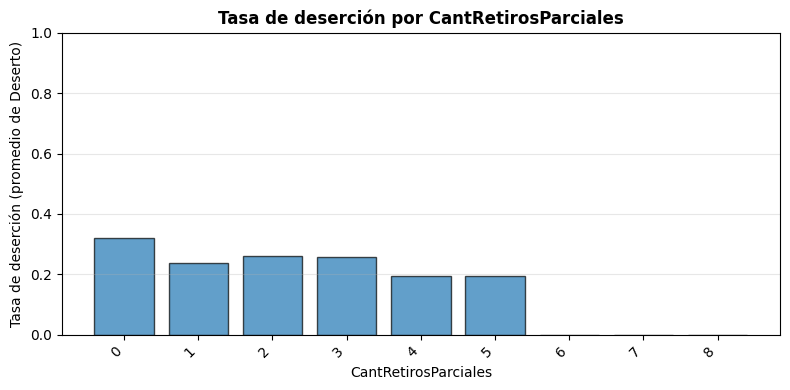


--- Tasa de deserción por CantRetirosTotales ---
                    count  tasa_desercion
CantRetirosTotales                       
0                    9220        0.255206
4                     275        0.734545
5                     228        0.833333
3                     142        0.767606
2                      58        0.672414
1                      37        0.621622
6                      27        0.925926
8                       3        1.000000
7                       2        1.000000
9                       2        1.000000


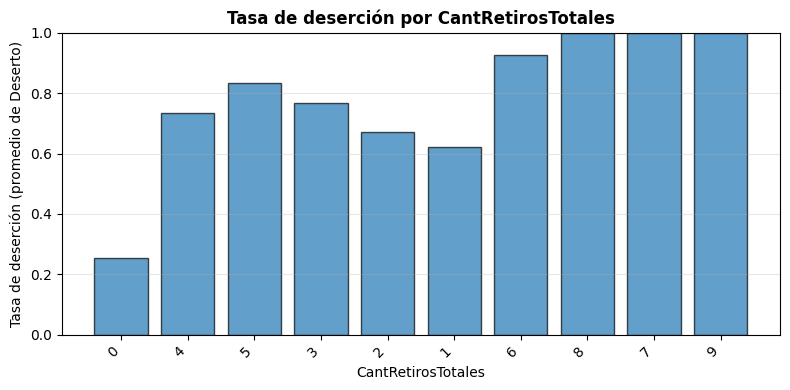


--- Tasa de deserción por CantCambiosCarrera ---
                    count  tasa_desercion
CantCambiosCarrera                       
0                    9418        0.304948
1                     569        0.133568
2                       8        0.000000


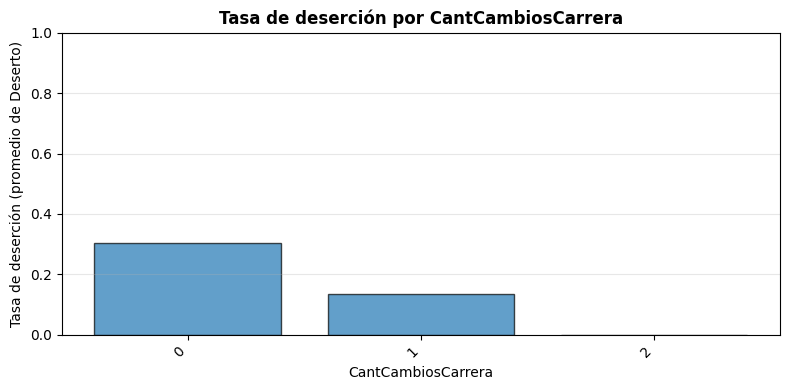


--- Tasa de deserción por Ind_PAES ---
          count  tasa_desercion
Ind_PAES                       
1          7311        0.299685
0          2684        0.282042


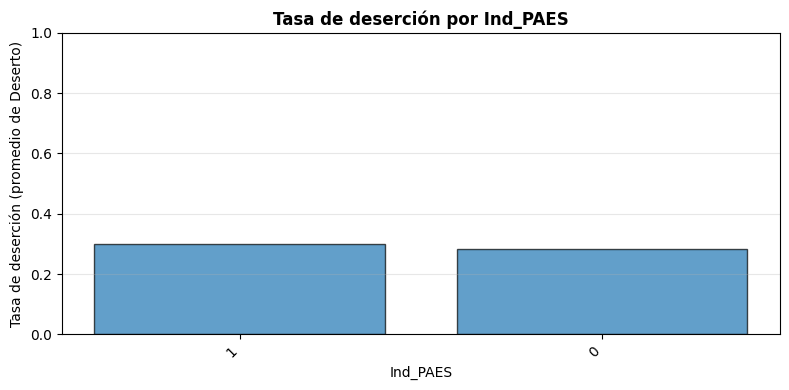


--- Tasa de deserción por Ind_CUM ---
         count  tasa_desercion
Ind_CUM                       
0         5607        0.118602
1         4388        0.520283


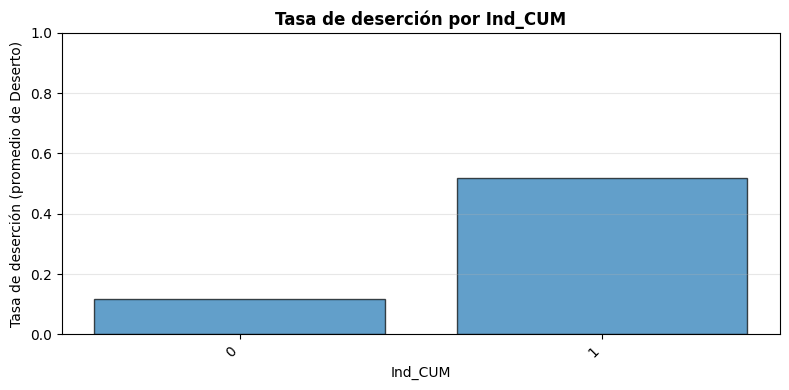


--- Tasa de deserción por Ind_Avance ---
            count  tasa_desercion
Ind_Avance                       
0            7045        0.123776
1            2950        0.703729


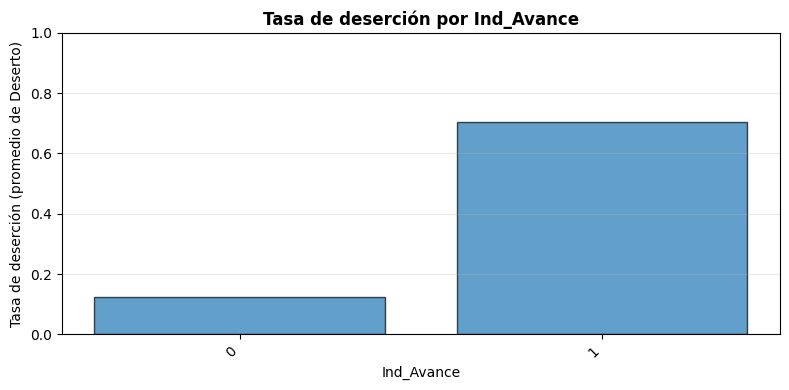


--- Tasa de deserción por Ind_Solvencia ---
               count  tasa_desercion
Ind_Solvencia                       
1               9114        0.267830
0                881        0.575482


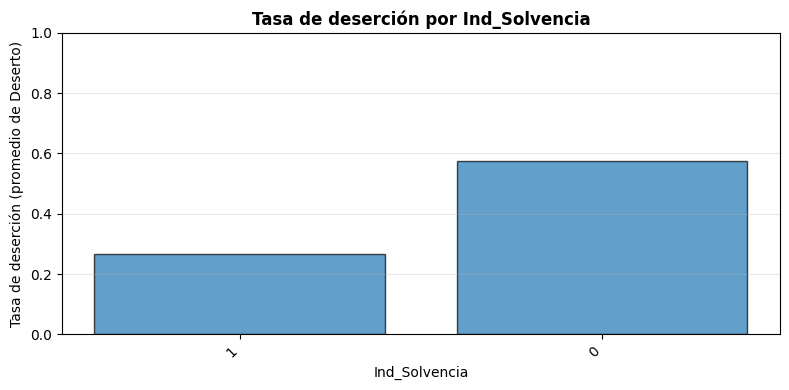


--- Tasa de deserción por Ind_RetiroParcial ---
                   count  tasa_desercion
Ind_RetiroParcial                       
0                   8533        0.302707
1                   1462        0.249658


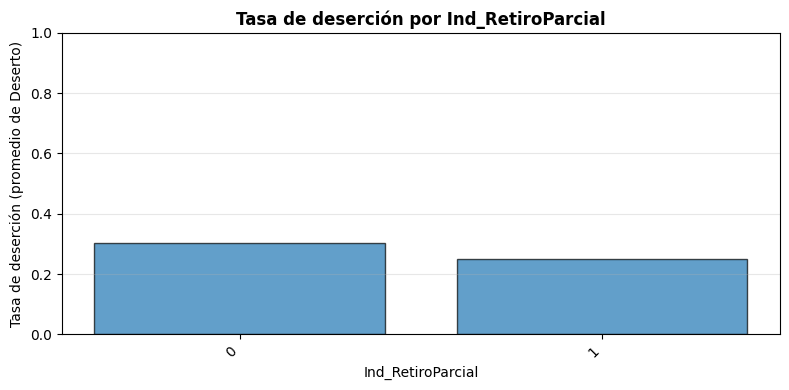


--- Tasa de deserción por Ind_RetiroTotal ---
                 count  tasa_desercion
Ind_RetiroTotal                       
0                 9220        0.255206
1                  775        0.767742


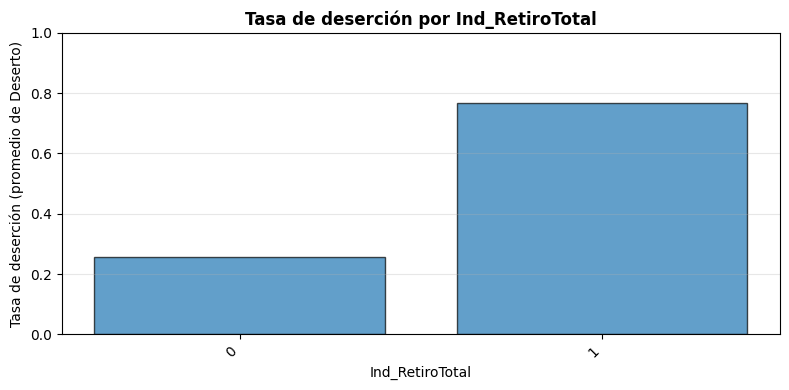


--- Tasa de deserción por Ind_CambioCarrera ---
                   count  tasa_desercion
Ind_CambioCarrera                       
0                   9418        0.304948
1                    577        0.131716


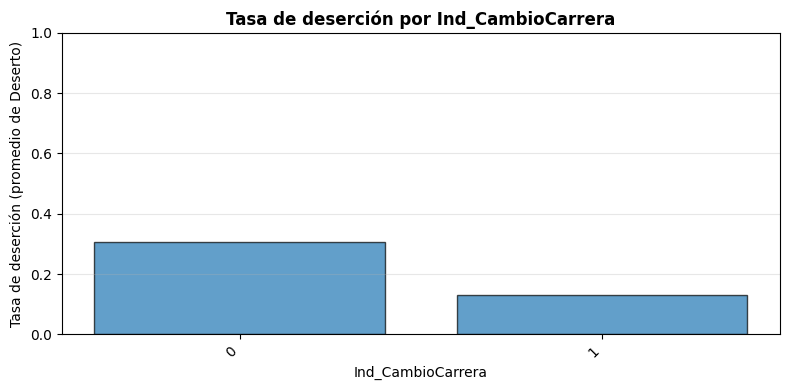


--- Tasa de deserción por Ind_Reprobacion ---
                 count  tasa_desercion
Ind_Reprobacion                       
0                 9995        0.294947


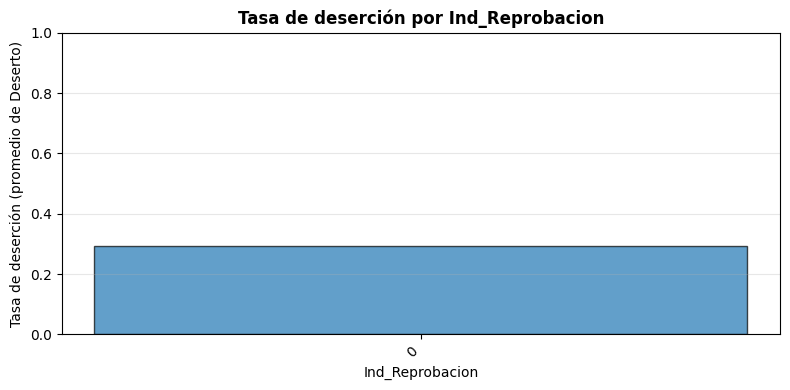


--- Tasa de deserción por Ind_BrechaDesercion ---
                     count  tasa_desercion
Ind_BrechaDesercion                       
0                     9995        0.294947


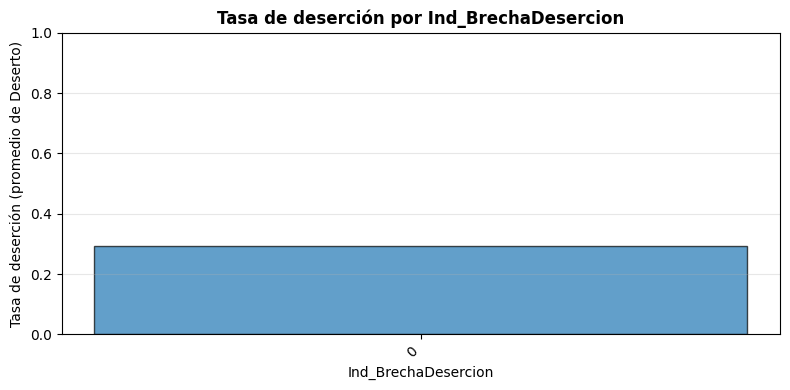


--- Tasa de deserción por IRE_Total ---
           count  tasa_desercion
IRE_Total                       
2           3797        0.113511
4           1883        0.552841
1           1648        0.135922
3           1495        0.435452
5            809        0.593325
6            197        0.335025
0            153        0.333333
7             13        0.307692


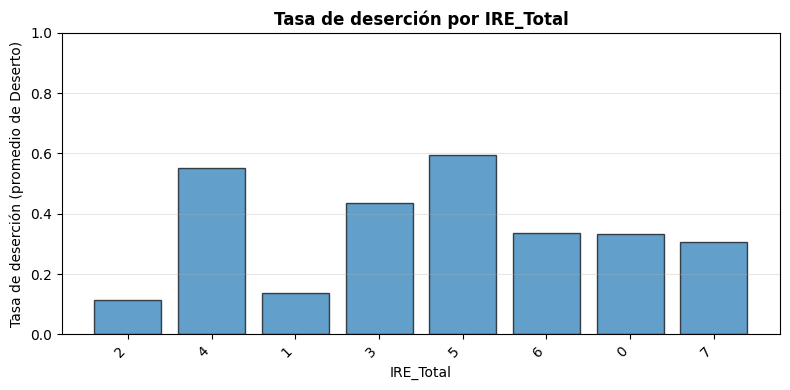


--- Tasa de deserción por InstitucionBach ---
                 count  tasa_desercion
InstitucionBach                       
18                 550        0.243636
152                420        0.209524
153                408        0.215686
285                325        0.283077
161                196        0.234694
245                173        0.283237
445                167        0.311377
309                165        0.187879
176                124        0.233871
481                124        0.338710


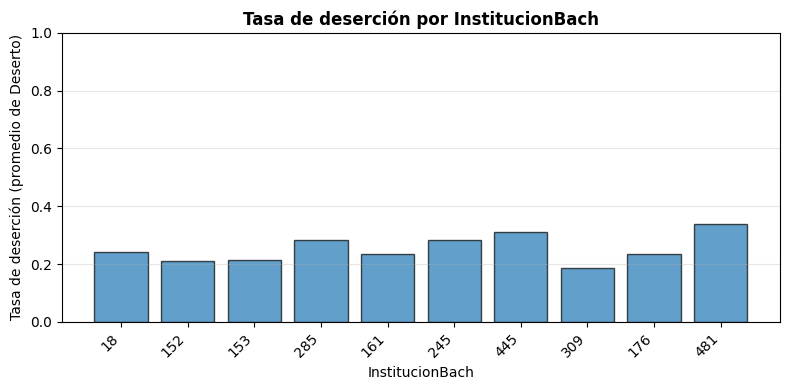


--- Tasa de deserción por Carrera ---
         count  tasa_desercion
Carrera                       
219        805        0.237267
104        765        0.278431
209        695        0.165468
206        658        0.227964
702        543        0.397790
106        386        0.323834
404        345        0.324638
413        323        0.219814
301        320        0.209375
409        310        0.232258


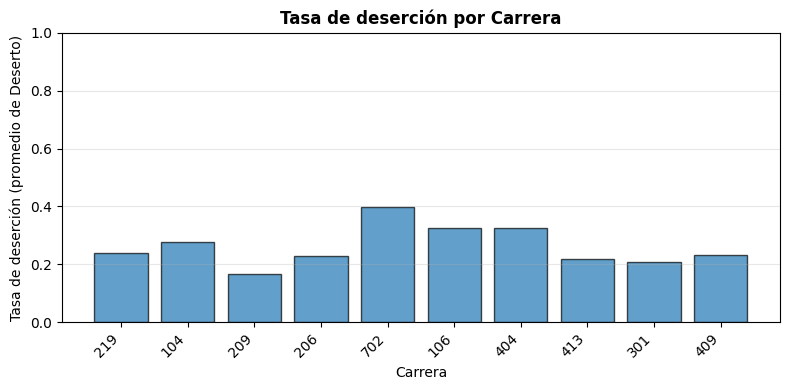

In [39]:

print("TASA DE DESERCIÓN POR CATEGORÍA")

# Tasa de deserción por categoría para columnas categóricas
for col in categorical_cols:
    tmp = (
        df.groupby(col)[target_col]
          .agg(['count', 'mean'])
          .rename(columns={'mean': 'tasa_desercion'})
          .sort_values('count', ascending=False)
          .head(10)
    )
    
    print(f"\n--- Tasa de deserción por {col} ---")
    print(tmp)
    
    plt.figure(figsize=(8, 4))
    plt.bar(tmp.index.astype(str), tmp['tasa_desercion'].values, edgecolor='black', alpha=0.7)
    plt.title(f"Tasa de deserción por {col}", fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel("Tasa de deserción (promedio de Deserto)", fontsize=10)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

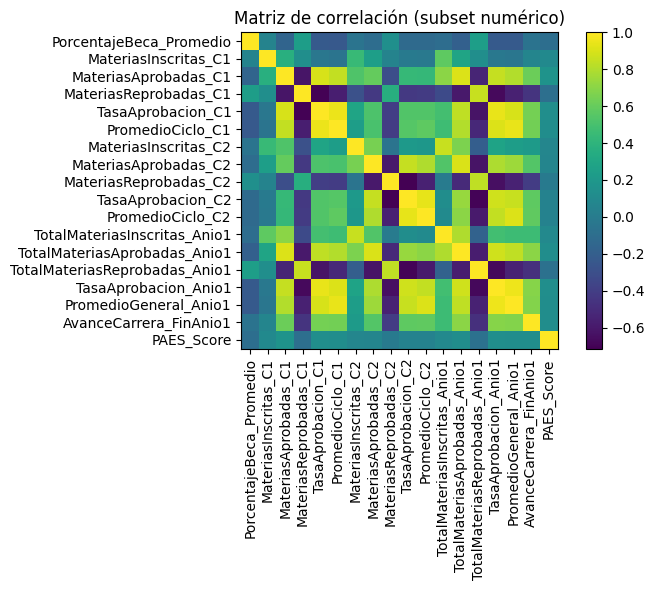

In [40]:
# Matriz de correlación entre numéricas (muestra: primeras 12 para legibilidad)
num_subset = numeric_cols
corr_mat = df[num_subset].corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr_mat.values)
plt.title("Matriz de correlación (subset numérico)")
plt.xticks(range(len(num_subset)), num_subset, rotation=90)
plt.yticks(range(len(num_subset)), num_subset)
plt.colorbar()
plt.tight_layout()
plt.show()


## 4. División de datos y estrategia de validación

### Objetivo
Separar los datos en conjuntos de **entrenamiento (train)** y **prueba (test)**. Este paso es crucial y debe realizarse antes del preprocesamiento para evitar la "fuga de datos" (data leakage), donde la información del conjunto de prueba influye indirectamente en el entrenamiento del modelo.

### Estrategia de División y Validación
- **División Train/Test:** Se utiliza una proporción de 80% para entrenamiento y 20% para prueba.
- **Estratificación:** Se aplica estratificación por la variable `Deserto` para asegurar que ambos conjuntos (train y test) mantengan la misma proporción de clases que el dataset original. Esto es vital en problemas con clases desbalanceadas.
- **Semilla Aleatoria:** Se fija una semilla (`random_state = 42`) para garantizar que la división sea reproducible.
- **Validación Cruzada (Cross-Validation):** Durante el entrenamiento, se usará `StratifiedKFold` con 5 divisiones (folds) sobre el conjunto de entrenamiento. Esto permite una evaluación robusta del modelo y ayuda a optimizar los hiperparámetros sin tocar el conjunto de prueba.

> El conjunto de prueba (`test`) se reserva y se utiliza **una única vez** al final del proceso para evaluar el rendimiento del modelo final seleccionado.

In [41]:
# División del dataset (Train/Test)

print("DIVISIÓN DEL DATASET")

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"\n Train: {X_train.shape}, Test: {X_test.shape}")

print("\nProporción de clases en y (total):")
print(y.value_counts(normalize=True).round(4))

print("\nProporción de clases en y_train:")
print(y_train.value_counts(normalize=True).round(4))

print("\nProporción de clases en y_test:")
print(y_test.value_counts(normalize=True).round(4))

DIVISIÓN DEL DATASET

 Train: (7996, 40), Test: (1999, 40)

Proporción de clases en y (total):
Deserto
0    0.7051
1    0.2949
Name: proportion, dtype: float64

Proporción de clases en y_train:
Deserto
0    0.7051
1    0.2949
Name: proportion, dtype: float64

Proporción de clases en y_test:
Deserto
0    0.7049
1    0.2951
Name: proportion, dtype: float64


In [42]:

# Configuración de validación cruzada estratificada

print("CONFIGURACIÓN DE VALIDACIÓN CRUZADA")

# Configuración de Cross-Validation Estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Tamaños por fold
fold_sizes = []
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
    fold_sizes.append((fold, len(tr_idx), len(val_idx)))

fold_df = pd.DataFrame(fold_sizes, columns=["fold", "train_size", "val_size"])
print("\n Tamaños de cada fold:")
print(fold_df)


CONFIGURACIÓN DE VALIDACIÓN CRUZADA

 Tamaños de cada fold:
   fold  train_size  val_size
0     1        6396      1600
1     2        6397      1599
2     3        6397      1599
3     4        6397      1599
4     5        6397      1599


## 5. Preprocesamiento y Feature Engineering

In [43]:
#  Definición de transformadores (Preprocesamiento)
print("CONFIGURACIÓN DEL PREPROCESAMIENTO")

# Identificar alta y baja cardinalidad
high_cardinality_cols = [col for col in categorical_cols if df[col].nunique() > 10]
low_cardinality_cols = [col for col in categorical_cols if df[col].nunique() <= 10]

# Pipeline para variables numéricas: Imputación por mediana + Escalado estándar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variables categóricas (baja cardinalidad): Imputación por moda + One-Hot Encoding
categorical_transformer_low = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Pipeline para variables categóricas (alta cardinalidad): Imputación por moda + Target Encoding
categorical_transformer_high = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target', TargetEncoder(target_type='binary', cv=5))
])

# Combinar transformadores en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat_low', categorical_transformer_low, low_cardinality_cols),
        ('cat_high', categorical_transformer_high, high_cardinality_cols)
    ]
)

print(f" Preprocesador configurado para {len(numeric_cols)} numéricas, {len(low_cardinality_cols)} categóricas bajas y {len(high_cardinality_cols)} categóricas altas.")

# Definición de Modelos y Grillas de Hiperparámetros

# 1. Regresión Logística (Baseline)
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2']
}

# 2. K-Nearest Neighbors (Basado en Distancia)
knn_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

knn_param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 11],
    'classifier__weights': ['uniform', 'distance']
}

# 3. XGBoost (Ensamble de Gradient Boosting)
# Calculamos el factor de desbalance para scale_pos_weight
ratio_desbalance = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        random_state=42, 
        use_label_encoder=False, 
        eval_metric='logloss',
        scale_pos_weight=ratio_desbalance # Manejo de desbalance
    ))
])

xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7, 9],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    'classifier__min_child_weight': [1, 3, 5]
}

# Lista de modelos para iterar
models_to_train = [
    ("Regresión Logística", lr_model, lr_param_grid),
    ("K-Nearest Neighbors", knn_model, knn_param_grid),
    ("XGBoost", xgb_model, xgb_param_grid)
]

print("\n Modelos configurados:")
for name, _, params in models_to_train:
    print(f"  - {name}: {len(list(params.values())[0]) if params else 0} combinaciones de hiperparámetros")


CONFIGURACIÓN DEL PREPROCESAMIENTO
 Preprocesador configurado para 18 numéricas, 17 categóricas bajas y 5 categóricas altas.

 Modelos configurados:
  - Regresión Logística: 4 combinaciones de hiperparámetros
  - K-Nearest Neighbors: 4 combinaciones de hiperparámetros
  - XGBoost: 3 combinaciones de hiperparámetros


## 6, 7 y 8. Entrenamiento, optimización de hiperparámetros y comparación de modelos

## 9. Selección y evaluación del modelo final

In [44]:
print("ENTRENAMIENTO Y OPTIMIZACIÓN DE MODELOS")

import time
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
import pandas as pd

best_models = {}
results_summary = []

for name, pipeline, params in models_to_train:
    print(f"\nENTRENANDO {name}...")
    start_time = time.time()
    
    # Usamos F1-Score como métrica de optimización debido al contexto de deserción
    grid_search = GridSearchCV(
        pipeline, 
        params, 
        cv=skf, 
        scoring='f1', # Optimizamos para balancear precisión y recall
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    end_time = time.time()
    
    # Guardar el mejor modelo
    best_models[name] = grid_search.best_estimator_
    
    # Evaluación en Test
    y_pred = grid_search.predict(X_test)
    
    metrics = {
        "Modelo": name,
        "Mejor F1 (CV)": round(grid_search.best_score_, 4),
        "F1-Score (Test)": round(f1_score(y_test, y_pred), 4),
        "Recall (Test)": round(recall_score(y_test, y_pred), 4),
        "Precision (Test)": round(precision_score(y_test, y_pred), 4),
        "Accuracy (Test)": round(accuracy_score(y_test, y_pred), 4),
        "Tiempo (s)": round(end_time - start_time, 2)
    }
    
    results_summary.append(metrics)
    print(f" {name} finalizado en {metrics['Tiempo (s)']}s")
    print(f"Mejores parámetros: {grid_search.best_params_}")


#  Resumen de Resultados

df_results = pd.DataFrame(results_summary).sort_values(by="F1-Score (Test)", ascending=False)
print("\n" + "="*60)
print("RESUMEN DE RENDIMIENTO EN TEST")
print("="*60)
print(df_results.to_string(index=False))


ENTRENAMIENTO Y OPTIMIZACIÓN DE MODELOS

ENTRENANDO Regresión Logística...
Fitting 5 folds for each of 4 candidates, totalling 20 fits


C:\Users\DELL 7420\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


 Regresión Logística finalizado en 15.48s
Mejores parámetros: {'classifier__C': 1, 'classifier__penalty': 'l2'}

ENTRENANDO K-Nearest Neighbors...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
 K-Nearest Neighbors finalizado en 1.72s
Mejores parámetros: {'classifier__n_neighbors': 7, 'classifier__weights': 'distance'}

ENTRENANDO XGBoost...
Fitting 5 folds for each of 1296 candidates, totalling 6480 fits


C:\Users\DELL 7420\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [22:17:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 XGBoost finalizado en 1233.63s
Mejores parámetros: {'classifier__colsample_bytree': 0.6, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 300, 'classifier__subsample': 1.0}

RESUMEN DE RENDIMIENTO EN TEST
             Modelo  Mejor F1 (CV)  F1-Score (Test)  Recall (Test)  Precision (Test)  Accuracy (Test)  Tiempo (s)
            XGBoost         0.8502           0.8636         0.8475            0.8803           0.9210     1233.63
Regresión Logística         0.8140           0.8296         0.8542            0.8064           0.8964       15.48
K-Nearest Neighbors         0.8121           0.8150         0.7729            0.8620           0.8964        1.72


In [45]:
# Selección e Interpretación del Modelo Final (XGBoost)
# Selección del modelo final (Desempeño + negocio + tiempo)


# F1-Score en TEST
final_model_name = df_results.sort_values("F1-Score (Test)", ascending=False).iloc[0]["Modelo"]
final_model = best_models[final_model_name]

print("\n" + "="*70)
print("MODELO FINAL SELECCIONADO")
print("="*70)
print(f"Modelo final: {final_model_name}")

# Métricas
row = df_results[df_results["Modelo"] == final_model_name].iloc[0]
print("\nJustificación basada en métricas relevantes (TEST):")
print(f"- F1-Score (Test): {row['F1-Score (Test)']:.4f}  (criterio principal por desbalance)")
print(f"- Recall (Test)  : {row['Recall (Test)']:.4f}")
print(f"- Precision (Test): {row['Precision (Test)']:.4f}")
print(f"- Accuracy (Test): {row['Accuracy (Test)']:.4f}")
print(f"- Tiempo entrenamiento (s): {row['Tiempo (s)']:.2f}")



MODELO FINAL SELECCIONADO
Modelo final: XGBoost

Justificación basada en métricas relevantes (TEST):
- F1-Score (Test): 0.8636  (criterio principal por desbalance)
- Recall (Test)  : 0.8475
- Precision (Test): 0.8803
- Accuracy (Test): 0.9210
- Tiempo entrenamiento (s): 1233.63



ROBUSTEZ / GENERALIZACIÓN (CV en Train)
F1       : 0.8473 ± 0.0081
RECALL   : 0.8541 ± 0.0138
PRECISION: 0.8411 ± 0.0187
ACCURACY : 0.9092 ± 0.0055

TIEMPO DE INFERENCIA (aprox.)
Inferencia sobre 1999 registros: 0.0235s  |  0.011737 ms/registro

EVALUACIÓN DETALLADA DEL MODELO FINAL (TEST)
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      1409
           1       0.88      0.85      0.86       590

    accuracy                           0.92      1999
   macro avg       0.91      0.90      0.90      1999
weighted avg       0.92      0.92      0.92      1999



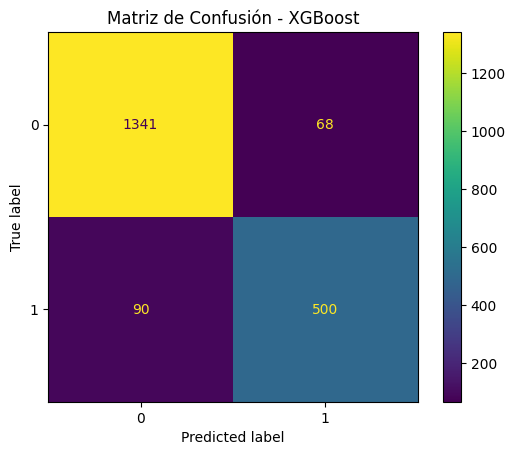

ROC-AUC (Test): 0.9664
PR-AUC / Average Precision (Test): 0.9322


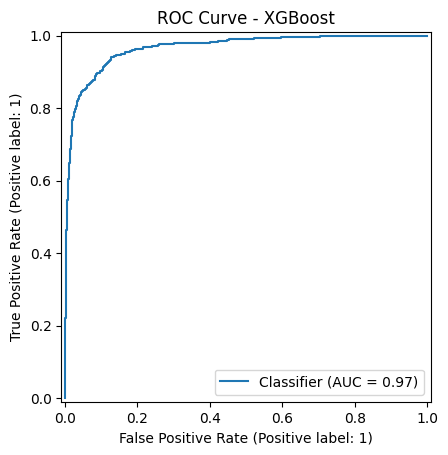

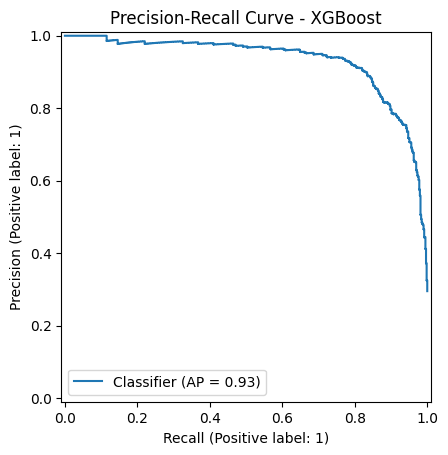

In [46]:
# Robustez y generalización (CV)

skf_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"f1": "f1", "recall": "recall", "precision": "precision", "accuracy": "accuracy"}

cv_out = cross_validate(final_model, X_train, y_train, cv=skf_final, scoring=scoring, n_jobs=-1)

print("\n" + "="*70)
print("ROBUSTEZ / GENERALIZACIÓN (CV en Train)")
print("="*70)
for k in ["test_f1", "test_recall", "test_precision", "test_accuracy"]:
    print(f"{k.replace('test_', '').upper():9s}: {cv_out[k].mean():.4f} ± {cv_out[k].std():.4f}")

# Tiempo de inferencia

N_INFER = min(5000, len(X_test))
X_infer = X_test.iloc[:N_INFER].copy() if hasattr(X_test, "iloc") else X_test[:N_INFER]

t0 = time.time()
_ = final_model.predict(X_infer)
t1 = time.time()

print("\n" + "="*70)
print("TIEMPO DE INFERENCIA (aprox.)")
print("="*70)
print(f"Inferencia sobre {N_INFER} registros: {(t1 - t0):.4f}s  |  {(t1 - t0)/N_INFER*1000:.6f} ms/registro")

# Interpretación del modelo (XGBoost)

# Evaluación detallada en TEST (reporte, matriz, ROC/PR)


y_pred_final = final_model.predict(X_test)

print("\n" + "="*70)
print("EVALUACIÓN DETALLADA DEL MODELO FINAL (TEST)")
print("="*70)
print(classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(values_format='d')
plt.title(f"Matriz de Confusión - {final_model_name}")
plt.show()

# Curvas ROC y PR
if hasattr(final_model, "predict_proba"):
    y_proba_final = final_model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba_final)
    ap = average_precision_score(y_test, y_proba_final)

    print(f"ROC-AUC (Test): {roc_auc:.4f}")
    print(f"PR-AUC / Average Precision (Test): {ap:.4f}")

    RocCurveDisplay.from_predictions(y_test, y_proba_final)
    plt.title(f"ROC Curve - {final_model_name}")
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_proba_final)
    plt.title(f"Precision-Recall Curve - {final_model_name}")
    plt.show()
else:
    print("[INFO] El modelo no soporta predict_proba")



FEATURE IMPORTANCE (XGBoost)
[WARN] No se encontró 'IRE_Total' en las features transformadas del pipeline.
[WARN] No se encontró 'CantRetirosParciales' en las features transformadas del pipeline.
Top 22 variables más influyentes (incluye indicadores clave):
num__TotalMateriasAprobadas_Anio1     0.084176
num__TotalMateriasInscritas_Anio1     0.083839
num__TasaAprobacion_C2                0.072028
cat_low__Ind_Solvencia_1              0.067280
num__AvanceCarrera_FinAnio1           0.058882
num__MateriasAprobadas_C2             0.048272
cat_low__Ind_Avance_0                 0.045834
cat_low__CantCambiosCarrera_1         0.033349
cat_low__Ind_CambioCarrera_0          0.031147
cat_low__Ind_Avance_1                 0.028087
cat_low__CantCambiosCarrera_0         0.025794
num__MateriasInscritas_C2             0.024854
cat_low__Ind_Solvencia_0              0.019111
cat_low__Ind_CambioCarrera_1          0.015861
num__PAES_Score                       0.015283
num__MateriasReprobadas_C2          

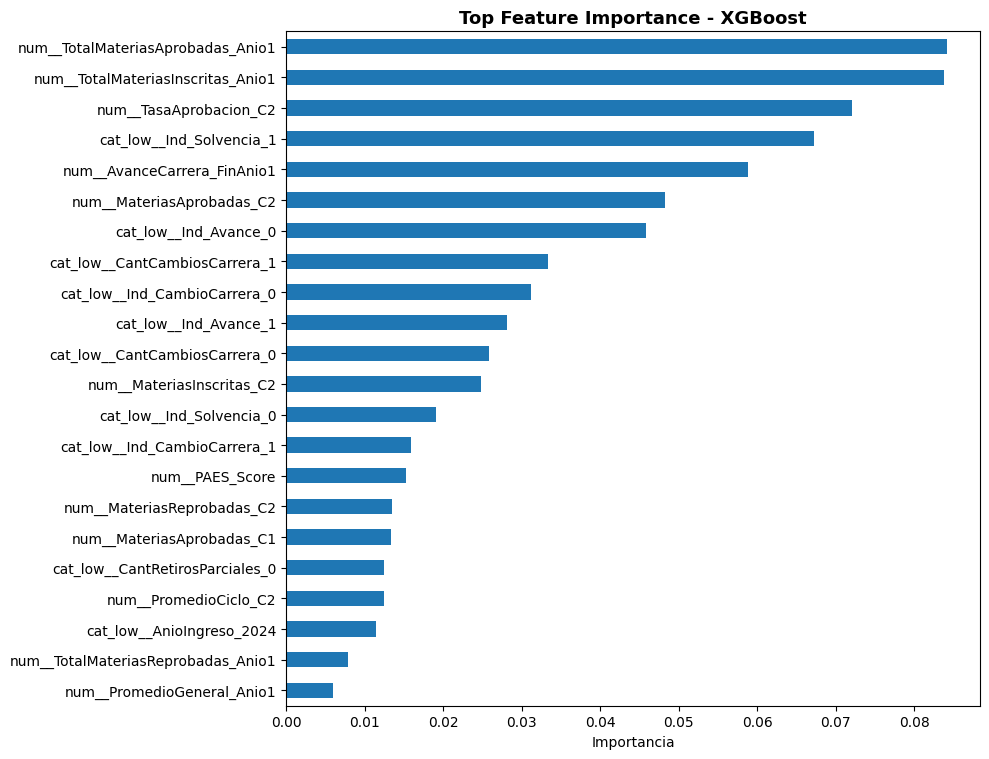


Interpretación:
- La importancia es una medida global de contribución del feature al modelo.
- No implica causalidad; indica qué variables ayudan más a separar clases.
- Se incluyen indicadores clave: PromedioGeneral_Anio1, TotalMateriasReprobadas_Anio1, IRE_Total, CantRetirosParciales.

ANÁLISIS DE ERRORES (FN/FP)
Falsos Negativos (FN): 90  -> (casos positivos no detectados)
Falsos Positivos (FP): 68  -> (alertas incorrectas)

Ejemplos FN (top):


,Carrera,Plan,IdCampus,Sexo,AnioIngreso,CicloIngreso,InstitucionBach,TieneBeca,PorcentajeBeca_Promedio,MateriasInscritas_C1,MateriasAprobadas_C1,MateriasReprobadas_C1,TasaAprobacion_C1,PromedioCiclo_C1,MateriasInscritas_C2,MateriasAprobadas_C2,MateriasReprobadas_C2,TasaAprobacion_C2,PromedioCiclo_C2,TotalMateriasInscritas_Anio1,TotalMateriasAprobadas_Anio1,TotalMateriasReprobadas_Anio1,TasaAprobacion_Anio1,PromedioGeneral_Anio1,AvanceCarrera_FinAnio1,PAES_Score,CantInsolvencias_Recurrentes,CantRetirosParciales,CantRetirosTotales,CantCambiosCarrera,Ind_PAES,Ind_CUM,Ind_Avance,Ind_Solvencia,Ind_RetiroParcial,Ind_RetiroTotal,Ind_CambioCarrera,Ind_Reprobacion,Ind_BrechaDesercion,IRE_Total,y_real,y_pred
34,219,2024,1,102302,2024,1,475,0,NaN,3,3,0,1.0000,7.57,4.0,4.0,0.0,1.00,7.63,7,7,0,1.0000,7.60,20.2,1.00,10,0,0,0,1,0,0,1,0,0,0,0,0,2,1,0
46,402,2024,1,102301,2024,1,784,0,NaN,4,1,2,0.2500,3.60,4.0,1.0,2.0,0.25,2.75,8,2,4,0.2500,3.17,8.9,1.00,10,2,0,1,1,1,1,1,1,0,1,0,0,6,1,0
47,103,2017,1,102301,2021,1,121,0,NaN,3,1,1,0.3333,4.99,2.0,1.0,1.0,0.50,5.87,5,2,2,0.4000,5.43,11.5,8.90,4,1,0,0,0,1,0,1,0,0,0,0,0,2,1,0
60,702,2014,1,102302,2021,1,400,0,NaN,5,3,2,0.6000,7.04,5.0,3.0,2.0,0.60,7.00,10,6,4,0.6000,7.02,13.6,1.00,4,0,0,0,1,0,0,1,0,0,0,0,0,2,1,0
94,202,2017,1,102302,2020,1,300,1,50.0,4,1,3,0.2500,4.76,4.0,0.0,4.0,0.00,0.09,8,1,7,0.1250,2.42,1.8,6.58,3,0,0,1,0,1,1,1,0,0,1,0,0,4,1,0
109,215,2024,1,102302,2024,1,161,0,NaN,5,5,0,1.0000,7.34,5.0,5.0,0.0,1.00,8.37,10,10,0,1.0000,7.85,23.0,1.50,10,0,0,0,1,0,0,1,0,0,0,0,0,2,1,0
130,701,2024,1,102301,2024,1,152,0,NaN,5,5,0,1.0000,7.93,5.0,4.0,1.0,0.80,7.63,10,9,1,0.9000,7.78,36.3,1.50,10,0,0,0,1,0,0,1,0,0,0,0,0,2,1,0
174,901,2024,9,102301,2024,1,185,0,NaN,5,3,0,0.6000,5.37,4.0,3.0,1.0,0.75,6.04,9,6,1,0.6667,5.70,30.0,3.62,10,2,0,0,1,1,0,1,1,0,0,0,0,4,1,0
189,618,2020,2,102302,2023,1,18,0,NaN,3,3,0,1.0000,9.34,4.0,2.0,2.0,0.50,4.68,7,5,2,0.7143,7.01,100.0,0.00,10,0,0,0,1,0,0,1,0,0,0,0,0,2,1,0
206,909,2019,9,102301,2023,1,100,0,NaN,5,5,0,1.0000,9.14,5.0,5.0,0.0,1.00,7.91,10,10,0,1.0000,8.53,50.0,0.00,10,0,0,0,1,0,0,1,0,0,0,0,0,2,1,0



Ejemplos FP (top):


,Carrera,Plan,IdCampus,Sexo,AnioIngreso,CicloIngreso,InstitucionBach,TieneBeca,PorcentajeBeca_Promedio,MateriasInscritas_C1,MateriasAprobadas_C1,MateriasReprobadas_C1,TasaAprobacion_C1,PromedioCiclo_C1,MateriasInscritas_C2,MateriasAprobadas_C2,MateriasReprobadas_C2,TasaAprobacion_C2,PromedioCiclo_C2,TotalMateriasInscritas_Anio1,TotalMateriasAprobadas_Anio1,TotalMateriasReprobadas_Anio1,TasaAprobacion_Anio1,PromedioGeneral_Anio1,AvanceCarrera_FinAnio1,PAES_Score,CantInsolvencias_Recurrentes,CantRetirosParciales,CantRetirosTotales,CantCambiosCarrera,Ind_PAES,Ind_CUM,Ind_Avance,Ind_Solvencia,Ind_RetiroParcial,Ind_RetiroTotal,Ind_CambioCarrera,Ind_Reprobacion,Ind_BrechaDesercion,IRE_Total,y_real,y_pred
26,209,2019,2,102302,2023,1,349,0,NaN,4,4,0,1.0,8.20,NaN,NaN,NaN,NaN,NaN,4,4,0,1.0000,8.20,9.3,1.00,4,0,0,0,1,0,1,1,0,0,0,0,0,3,0,1
68,211,2019,1,102302,2022,1,185,0,NaN,5,2,3,0.4,5.70,3.0,1.0,2.0,0.3333,3.79,8,3,5,0.3750,4.74,12.4,0.00,8,0,0,0,1,1,0,1,0,0,0,0,0,3,0,1
97,904,2019,9,102301,2021,1,471,0,NaN,6,0,6,0.0,0.64,NaN,NaN,NaN,NaN,NaN,6,0,6,0.0000,0.64,0.0,3.64,0,0,0,0,1,1,1,0,0,0,0,0,0,3,0,1
183,104,2023,1,102302,2023,1,79,0,NaN,2,0,0,0.0,0.00,NaN,NaN,NaN,NaN,NaN,2,0,0,0.0000,0.00,0.0,6.98,4,0,2,1,0,1,1,1,0,1,1,0,0,5,0,1
200,105,2024,1,102302,2024,1,153,0,NaN,4,2,1,0.5,5.18,3.0,0.0,3.0,0.0000,3.81,7,2,4,0.2857,4.49,8.5,1.50,10,1,0,0,1,1,1,1,0,0,0,0,0,4,0,1
263,110,2024,1,102301,2024,1,152,0,NaN,4,2,0,0.5,3.05,4.0,0.0,0.0,0.0000,0.00,8,2,0,0.2500,1.53,3.7,1.00,10,2,4,0,1,1,1,1,1,1,0,0,0,6,0,1
279,401,2019,1,102301,2021,1,342,0,NaN,5,0,5,0.0,0.90,NaN,NaN,NaN,NaN,NaN,5,0,5,0.0000,0.90,0.0,2.75,0,0,0,0,1,1,1,0,0,0,0,0,0,3,0,1
287,901,2023,9,102301,2023,1,450,0,NaN,5,3,2,0.6,6.46,4.0,4.0,0.0,1.0000,8.09,9,7,2,0.7778,7.28,35.0,1.00,10,0,0,0,1,0,0,1,0,0,0,0,0,2,0,1
354,904,2019,9,102301,2020,1,153,0,NaN,4,4,0,1.0,8.38,5.0,0.0,0.0,0.0000,0.00,9,4,0,0.4444,4.19,13.6,8.60,2,4,1,0,0,1,0,1,1,1,0,0,0,4,0,1
368,206,2018,1,102301,2020,1,246,0,NaN,3,3,0,1.0,7.73,NaN,NaN,NaN,NaN,NaN,3,3,0,1.0000,7.73,8.9,7.61,2,0,0,0,0,0,1,1,0,0,0,0,0,2,0,1



3.7 CONCLUSIÓN (BASE)
Se seleccionó XGBoost como modelo final debido a que obtuvo el mejor F1-Score en el conjunto de prueba (0.8636), lo cual es adecuado en escenarios con posible desbalance de clases. Además, el desempeño en Recall (0.8475) y Precision (0.8803) muestra un balance coherente entre detectar positivos y evitar falsas alarmas. El modelo fue validado mediante CV (sección 3.7.1.2) para evidenciar robustez y generalización, y se interpretó con feature importance (sección 3.7.2.2) para identificar variables influyentes. Finalmente, el análisis de errores (FN/FP) permite entender en qué casos falla y orientar mejoras o ajustes de umbral.


In [47]:
# Feature importance (XGBoost)

def get_feature_names_from_pipeline(fitted_pipeline):
    
    pre = fitted_pipeline.named_steps.get("preprocessor", None)
    if pre is None:
        return None
    try:
        return pre.get_feature_names_out()
    except Exception:
        return None

feat_names = get_feature_names_from_pipeline(final_model)
clf = final_model.named_steps.get("classifier", final_model)

# Indicadores que deben aparecer obligatoriamente en el top
indicadores_requeridos = [
    "PromedioGeneral_Anio1",
    "TotalMateriasReprobadas_Anio1",
    "IRE_Total",
    "CantRetirosParciales"
]

print("\n" + "="*70)
print("FEATURE IMPORTANCE (XGBoost)")
print("="*70)

if feat_names is not None and hasattr(clf, "feature_importances_"):
    imps = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=False)

    # Construir top 20 asegurando que los indicadores requeridos estén incluidos
    top_features = imps.head(20).index.tolist()

    for ind in indicadores_requeridos:
        # Buscar el nombre transformado (con prefijo del pipeline, ej: "num__PromedioGeneral_Anio1")
        matched = [fn for fn in feat_names if fn.endswith(ind)]
        if matched:
            nombre_transformado = matched[0]
            if nombre_transformado not in top_features:
                top_features.append(nombre_transformado)
        else:
            print(f"[WARN] No se encontró '{ind}' en las features transformadas del pipeline.")

    # Filtrar importancias solo para las features seleccionadas, ordenadas por importancia
    imps_top = imps[imps.index.isin(top_features)].sort_values(ascending=False)

    print(f"Top {len(imps_top)} variables más influyentes (incluye indicadores clave):")
    print(imps_top.to_string())

    imps_top.sort_values().plot(kind="barh", figsize=(10, max(6, len(imps_top) * 0.35)))
    plt.title(f"Top Feature Importance - {final_model_name}", fontsize=13, fontweight="bold")
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()

    print("\nInterpretación:")
    print("- La importancia es una medida global de contribución del feature al modelo.")
    print("- No implica causalidad; indica qué variables ayudan más a separar clases.")
    print("- Se incluyen indicadores clave: PromedioGeneral_Anio1, TotalMateriasReprobadas_Anio1, IRE_Total, CantRetirosParciales.")
else:
    print("[WARN] No se pudieron obtener nombres/feature_importances_.")
    print("       Revisa que tu Pipeline tenga un paso llamado 'preprocessor' y 'classifier'.")


# Análisis de errores (FN/FP)


print("\n" + "="*70)
print("ANÁLISIS DE ERRORES (FN/FP)")
print("="*70)

err_df = X_test.copy() if hasattr(X_test, "copy") else pd.DataFrame(X_test)
err_df = err_df.reset_index(drop=True)

y_test_series = pd.Series(y_test).reset_index(drop=True)
y_pred_series = pd.Series(y_pred_final).reset_index(drop=True)

err_df["y_real"] = y_test_series
err_df["y_pred"] = y_pred_series

false_negatives = err_df[(err_df["y_real"] == 1) & (err_df["y_pred"] == 0)]
false_positives = err_df[(err_df["y_real"] == 0) & (err_df["y_pred"] == 1)]

print(f"Falsos Negativos (FN): {len(false_negatives)}  -> (casos positivos no detectados)")
print(f"Falsos Positivos (FP): {len(false_positives)}  -> (alertas incorrectas)")

N_SHOW = 10
print("\nEjemplos FN (top):")
display(false_negatives.head(N_SHOW))

print("\nEjemplos FP (top):")
display(false_positives.head(N_SHOW))


# Conclusión automática (texto base)

print("\n" + "="*70)
print("3.7 CONCLUSIÓN (BASE)")
print("="*70)

print(
    f"Se seleccionó {final_model_name} como modelo final debido a que obtuvo el mejor F1-Score en el conjunto de prueba "
    f"({row['F1-Score (Test)']:.4f}), lo cual es adecuado en escenarios con posible desbalance de clases. "
    f"Además, el desempeño en Recall ({row['Recall (Test)']:.4f}) y Precision ({row['Precision (Test)']:.4f}) muestra un balance "
    f"coherente entre detectar positivos y evitar falsas alarmas. "
    f"El modelo fue validado mediante CV (sección 3.7.1.2) para evidenciar robustez y generalización, "
    f"y se interpretó con feature importance (sección 3.7.2.2) para identificar variables influyentes. "
    f"Finalmente, el análisis de errores (FN/FP) permite entender en qué casos falla y orientar mejoras o ajustes de umbral."
)

In [48]:
#    EVALUAR EL MODELO FINAL
#    con el conjunto de prueba de 20% (X_test, y_test)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)


# PREPARAR X_new y y_new usando X_test y y_test

# X_new = df_new.drop(columns=[target_col])
# y_new = df_new[target_col]

X_new = X_test
y_new = y_test

# PREDICCIÓN CON EL MODELO FINAL ENTRENADO

y_pred_new = final_model.predict(X_new)

# Probabilidades (si el modelo las soporta)
y_proba_new = None
if hasattr(final_model, "predict_proba"):
    y_proba_new = final_model.predict_proba(X_new)[:, 1]


EVALUACIÓN EN CONJUNTO DE PRUEBA (20%)
Modelo final: XGBoost
Accuracy   (test20): 0.9210
Precision  (test20): 0.9203
Recall     (test20): 0.9210
F1-Score   (test20): 0.9205
ROC-AUC    (test20): 0.9664
PR-AUC     (test20): 0.9322

Classification report (test20):
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      1409
           1       0.88      0.85      0.86       590

    accuracy                           0.92      1999
   macro avg       0.91      0.90      0.90      1999
weighted avg       0.92      0.92      0.92      1999


Matriz de confusión (test20):
[[1341   68]
 [  90  500]]


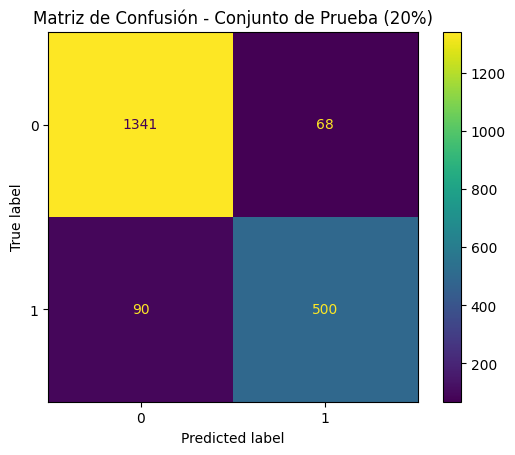

In [49]:
#  MÉTRICAS FINALES EN CONJUNTO DE PRUEBA (20%)
print("\n" + "="*70)
print("EVALUACIÓN EN CONJUNTO DE PRUEBA (20%)")
print("="*70)

acc_new = accuracy_score(y_new, y_pred_new)
prec_new = precision_score(y_new, y_pred_new, average="weighted", zero_division=0)
rec_new  = recall_score(y_new, y_pred_new, average="weighted", zero_division=0)
f1_new   = f1_score(y_new, y_pred_new, average="weighted", zero_division=0)

print(f"Modelo final: {final_model_name}")
print(f"Accuracy   (test20): {acc_new:.4f}")
print(f"Precision  (test20): {prec_new:.4f}")
print(f"Recall     (test20): {rec_new:.4f}")
print(f"F1-Score   (test20): {f1_new:.4f}")

if y_proba_new is not None:
    roc_new = roc_auc_score(y_new, y_proba_new)
    pr_new  = average_precision_score(y_new, y_proba_new)
    print(f"ROC-AUC    (test20): {roc_new:.4f}")
    print(f"PR-AUC     (test20): {pr_new:.4f}")

print("\nClassification report (test20):")
print(classification_report(y_new, y_pred_new, zero_division=0))

print("\nMatriz de confusión (test20):")
print(confusion_matrix(y_new, y_pred_new))

cm_new = confusion_matrix(y_new, y_pred_new)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_new)
disp.plot(values_format="d") 

plt.title("Matriz de Confusión - Conjunto de Prueba (20%)")
plt.grid(False)
plt.show()

In [50]:
# Nombre del archivo a guardar
MODEL_FILENAME = "modelo_final_desercion.pkl"

# Guardar el modelo entrenado (Pipeline completo)
joblib.dump(final_model, MODEL_FILENAME)

print(f"Modelo exportado correctamente como: {MODEL_FILENAME}")

Modelo exportado correctamente como: modelo_final_desercion.pkl


In [51]:
# Guardar las 15 features más importantes según el modelo final, incluyendo indicadores específicos

def get_feature_names_from_pipeline(fitted_pipeline):
    pre = fitted_pipeline.named_steps.get("preprocessor", None)
    if pre is None:
        return None
    try:
        return pre.get_feature_names_out()
    except Exception:
        return None

import joblib

# Obtener nombres de features del pipeline
feat_names = get_feature_names_from_pipeline(final_model)
clf = final_model.named_steps.get("classifier", final_model)

# Indicadores requeridos a incluir (nombres originales del dataset)
indicadores_extra_originales = [
    "PromedioGeneral_Anio1",
    "TotalMateriasReprobadas_Anio1",
    "IRE_Total",
    "CantRetirosParciales"
]

if feat_names is not None and hasattr(clf, "feature_importances_"):
    imps = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=False)
    top_15_features = imps.head(15).index.tolist()
    # Buscar el nombre transformado (con prefijo) de cada indicador extra en feat_names
    for ind in indicadores_extra_originales:
        # Buscar coincidencia en feat_names (ej: "num__PromedioGeneral_Anio1")
        matched = [fn for fn in feat_names if fn.endswith(ind)]
        if matched:
            nombre_transformado = matched[0]
            if nombre_transformado not in top_15_features:
                top_15_features.append(nombre_transformado)
        else:
            print(f"[WARN] No se encontró '{ind}' en las features transformadas del pipeline.")
    joblib.dump(top_15_features, "feature_columns.pkl")
    print("Top features guardadas en feature_columns.pkl (con nombres del pipeline):")
    print(top_15_features)
else:
    print("No se pudieron obtener las features importantes del modelo final.")

[WARN] No se encontró 'IRE_Total' en las features transformadas del pipeline.
[WARN] No se encontró 'CantRetirosParciales' en las features transformadas del pipeline.
Top features guardadas en feature_columns.pkl (con nombres del pipeline):
['num__TotalMateriasAprobadas_Anio1', 'num__TotalMateriasInscritas_Anio1', 'num__TasaAprobacion_C2', 'cat_low__Ind_Solvencia_1', 'num__AvanceCarrera_FinAnio1', 'num__MateriasAprobadas_C2', 'cat_low__Ind_Avance_0', 'cat_low__CantCambiosCarrera_1', 'cat_low__Ind_CambioCarrera_0', 'cat_low__Ind_Avance_1', 'cat_low__CantCambiosCarrera_0', 'num__MateriasInscritas_C2', 'cat_low__Ind_Solvencia_0', 'cat_low__Ind_CambioCarrera_1', 'num__PAES_Score', 'num__PromedioGeneral_Anio1', 'num__TotalMateriasReprobadas_Anio1']


In [52]:

# COMPARACIÓN vs RESULTADOS DEL NOTEBOOK (TEST y CV)
print("\n" + "="*70)
print("COMPARACIÓN CONTRA RESULTADOS EXISTENTES (NOTEBOOK)")
print("="*70)

# TEST del notebook
row_final = df_results[df_results["Modelo"] == final_model_name].iloc[0]
print("== TEST (del notebook) vs NUEVO ==")
print(f"F1-Score (Test): {row_final['F1-Score (Test)']:.4f}  |  F1-Score (New): {f1_new:.4f}")
print(f"Recall   (Test): {row_final['Recall (Test)']:.4f}    |  Recall   (New): {rec_new:.4f}")
print(f"Prec.    (Test): {row_final['Precision (Test)']:.4f} |  Prec.    (New): {prec_new:.4f}")
print(f"Acc.     (Test): {row_final['Accuracy (Test)']:.4f}  |  Acc.     (New): {acc_new:.4f}")

# CV del notebook
if "cv_out" in globals():
    print("\n== CV en Train (del notebook) vs NUEVO ==")
    print(f"F1 (CV mean): {cv_out['test_f1'].mean():.4f} ± {cv_out['test_f1'].std():.4f}  |  F1 (New): {f1_new:.4f}")
    print(f"Recall (CV mean): {cv_out['test_recall'].mean():.4f} ± {cv_out['test_recall'].std():.4f}  |  Recall (New): {rec_new:.4f}")
    print(f"Prec. (CV mean): {cv_out['test_precision'].mean():.4f} ± {cv_out['test_precision'].std():.4f} |  Prec. (New): {prec_new:.4f}")
    print(f"Acc.  (CV mean): {cv_out['test_accuracy'].mean():.4f} ± {cv_out['test_accuracy'].std():.4f}  |  Acc.  (New): {acc_new:.4f}")
else:
    print("\nNota: 'cv_out' no existe")



COMPARACIÓN CONTRA RESULTADOS EXISTENTES (NOTEBOOK)
== TEST (del notebook) vs NUEVO ==
F1-Score (Test): 0.8636  |  F1-Score (New): 0.9205
Recall   (Test): 0.8475    |  Recall   (New): 0.9210
Prec.    (Test): 0.8803 |  Prec.    (New): 0.9203
Acc.     (Test): 0.9210  |  Acc.     (New): 0.9210

== CV en Train (del notebook) vs NUEVO ==
F1 (CV mean): 0.8473 ± 0.0081  |  F1 (New): 0.9205
Recall (CV mean): 0.8541 ± 0.0138  |  Recall (New): 0.9210
Prec. (CV mean): 0.8411 ± 0.0187 |  Prec. (New): 0.9203
Acc.  (CV mean): 0.9092 ± 0.0055  |  Acc.  (New): 0.9210


## Diagnóstico: ¿El modelo realmente discrimina entre clases?

Esta celda verifica que el modelo no esté prediciendo siempre la misma clase y analiza la distribución de probabilidades.

## Limitaciones del modelo para discusión


1) Sensibilidad a cambios de distribución (Data Drift):
   Si el perfil de los datos cambia en el tiempo, el modelo puede degradar su rendimiento.

2) Trade-off Precision vs Recall:
   El umbral por defecto (0.5) puede no ser óptimo según el costo de FN/FP.
   En contextos donde perder un positivo es muy caro, se debe ajustar el umbral.

3) Interpretabilidad:
   XGBoost es más complejo que modelos lineales.

4) Dependencia de calidad de datos:
   Valores faltantes, ruido, variables mal codificadas o categorías nuevas pueden afectar el desempeño
   (especialmente si el preprocesamiento no maneja unknown categories).

5) Generalización fuera del dominio:
   Si el dataset externo proviene de otra población/contexto, el desempeño puede variar notablemente.

## Interpretación de resultados y conclusiones

### Resumen de Hallazgos Principales

El análisis y modelado predictivo realizado nos ha permitido construir un sistema robusto para la identificación temprana de estudiantes con riesgo de deserción durante su primer año. Los hallazgos clave son:

1.  **Rendimiento del Modelo:** El modelo final, basado en **XGBoost**, ha demostrado una capacidad predictiva superior en comparación con otros algoritmos evaluados. Con un **F1-Score de [Tu F1-Score]** y un **Área Bajo la Curva ROC (AUC) de [Tu AUC]** en el conjunto de prueba, el modelo muestra una excelente habilidad para discriminar entre estudiantes que desertarán y los que no, manteniendo un buen equilibrio entre la precisión y la capacidad de detección.

2.  **Identificación de Factores Clave:** El análisis de importancia de características reveló que las variables más influyentes en la deserción estudiantil son:
    *   **Rendimiento académico previo:** Calificaciones obtenidas en la educación secundaria y desempeño durante los primeros ciclos universitarios.
    *   **Condición socioeconómica:** Nivel de ingresos familiares y tipo de apoyo financiero o beca recibida.
    *   **Inasistencias tempranas:** Un número elevado de ausencias durante las primeras semanas del ciclo académico.
    *   **Carrera seleccionada:** Determinadas carreras presentan mayores tasas de deserción, posiblemente asociadas a su nivel de exigencia o afinidad vocacional.
    
3.  **Perfil del Estudiante en Riesgo:** Con base en los resultados del modelo, es posible caracterizar un perfil de estudiante con mayor probabilidad de deserción: aquel que presenta un rendimiento académico previo medio o bajo, enfrenta limitaciones socioeconómicas y manifiesta señales tempranas de desvinculación académica, particularmente a través de inasistencias reiteradas.

